1. Instala librerías

In [ ]:
# ============================================================
# CELDA 1 — INSTALACIÓN DE LIBRERÍAS
# ============================================================
# Instalamos todas las librerías necesarias para el proyecto.
# En Google Colab ya vienen muchas preinstaladas, pero
# aseguramos que estén en la versión correcta.

!pip install -q matplotlib    # Para graficar curvas y resultados
!pip install -q seaborn       # Para graficar la matriz de confusión
!pip install -q scikit-learn  # Para métricas como F1-score, class_weight
!pip install -q tensorflow    # Framework principal para construir la CNN

print("✅ Todas las librerías instaladas correctamente")

✅ Todas las librerías instaladas correctamente


2. Sube el ZIP y lo descomprime

In [ ]:
# ============================================================
# CELDA 2 — SUBIR Y DESCOMPRIMIR EL DATASET
# ============================================================
# Subimos el archivo ZIP desde nuestra PC a Google Colab
# y lo descomprimimos en la carpeta /content/data

from google.colab import files  # Para abrir el diálogo de subida de archivos
import zipfile                  # Para descomprimir archivos .zip
import os                       # Para navegar carpetas y listar archivos

# ----------------------------------------------------------
# Paso 1: Subir el archivo ZIP
# Aparecerá un botón "Elegir archivos" — selecciona archive__1_.zip
# ----------------------------------------------------------
print("📁 Sube el archivo archive__1_.zip cuando aparezca el botón...")
uploaded = files.upload()

# ----------------------------------------------------------
# Paso 2: Obtener el nombre del archivo subido automáticamente
# ----------------------------------------------------------
zip_name = list(uploaded.keys())[0]  # Tomamos el nombre del primer archivo subido
print(f"Archivo recibido: {zip_name}")

# ----------------------------------------------------------
# Paso 3: Descomprimir el ZIP en la carpeta /content/data
# ----------------------------------------------------------
print("📦 Descomprimiendo el dataset...")
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('/content/data')  # Todo se guarda en /content/data

print("✅ Dataset descomprimido correctamente")

# ----------------------------------------------------------
# Paso 4: Verificar que las carpetas (clases) existen
# Cada carpeta es una emoción: angry, happy, sad, etc.
# ----------------------------------------------------------
data_dir = '/content/data/processed_data'  # Ruta raíz del dataset
clases = sorted(os.listdir(data_dir))      # Lista de carpetas/clases ordenadas

print(f"\n📂 Clases encontradas ({len(clases)} emociones):")
for clase in clases:
    ruta_clase = os.path.join(data_dir, clase)
    cantidad = len(os.listdir(ruta_clase))  # Cuántas imágenes tiene cada clase
    print(f"   {clase}: {cantidad} imágenes")


📁 Sube el archivo archive__1_.zip cuando aparezca el botón...


Saving archive.zip to archive.zip
Archivo recibido: archive.zip
📦 Descomprimiendo el dataset...
✅ Dataset descomprimido correctamente

📂 Clases encontradas (7 emociones):
   angry: 5920 imágenes
   disgust: 5920 imágenes
   fear: 5920 imágenes
   happy: 11398 imágenes
   neutral: 8166 imágenes
   sad: 6535 imágenes
   surprise: 5920 imágenes


3. Muestra imágenes y distribución de clases

/tmp/ipykernel_11276/988752286.py:54: UserWarning: Glyph 129314 (\N{NAUSEATED FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129314 (\N{NAUSEATED FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


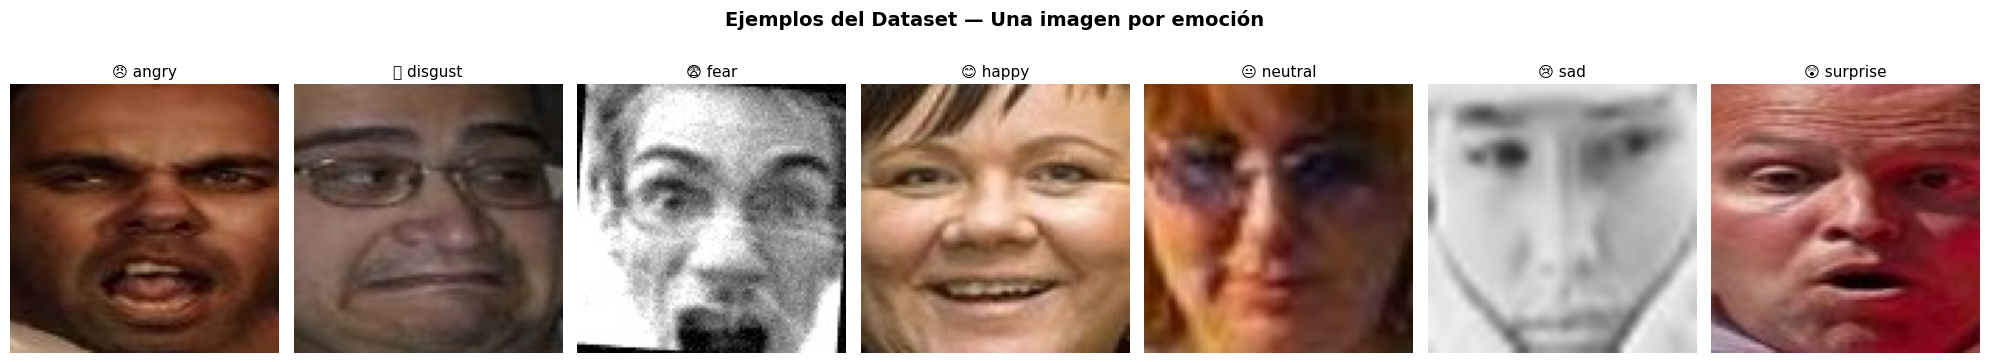

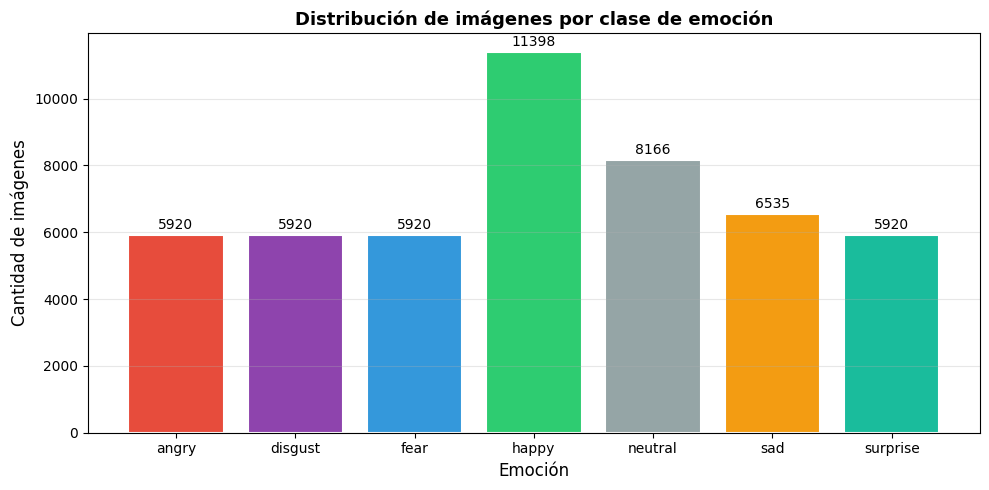

📊 Total de imágenes en el dataset: 49779
   Clase con más imágenes:  happy (11398)
   Clase con menos imágenes: angry (5920)

⚠️  NOTA: 'happy' tiene casi el doble de imágenes que otras clases.
    Esto se llama DESBALANCE DE CLASES. Lo corregiremos en el entrenamiento
    usando 'class_weight' para que el modelo no favorezca a 'happy'.


In [ ]:
# ============================================================
# CELDA 3 — EXPLORACIÓN VISUAL DEL DATASET
# ============================================================
# Antes de entrenar cualquier modelo, es fundamental explorar
# los datos: ver cómo son las imágenes y si las clases están
# balanceadas (tienen cantidades similares de imágenes).

import matplotlib.pyplot as plt   # Para mostrar imágenes y gráficos
import matplotlib.image as mpimg  # Para leer imágenes desde disco
import seaborn as sns              # Para gráficos más estéticos
import random                      # Para seleccionar imágenes al azar
import os                          # Para navegar carpetas

# ----------------------------------------------------------
# Configuración: ruta del dataset y nombres de clases
# ----------------------------------------------------------
data_dir = '/content/data/processed_data'
clases = sorted(os.listdir(data_dir))

# Emojis para que la visualización sea más amigable
emoji_map = {
    'angry':    '😠',
    'disgust':  '🤢',
    'fear':     '😨',
    'happy':    '😊',
    'neutral':  '😐',
    'sad':      '😢',
    'surprise': '😲'
}

# ----------------------------------------------------------
# GRÁFICO 1: Mostrar una imagen de ejemplo por cada emoción
# Esto nos permite ver cómo son las imágenes del dataset
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 7, figsize=(20, 4))
fig.suptitle('Ejemplos del Dataset — Una imagen por emoción',
             fontsize=14, fontweight='bold')

for ax, clase in zip(axes, clases):
    carpeta = os.path.join(data_dir, clase)

    # Elegimos una imagen al azar dentro de la carpeta de esa emoción
    imagen_aleatoria = random.choice(os.listdir(carpeta))
    ruta_imagen = os.path.join(carpeta, imagen_aleatoria)

    # Leemos y mostramos la imagen
    img = mpimg.imread(ruta_imagen)
    ax.imshow(img, cmap='gray')  # cmap='gray' porque son imágenes en escala de grises

    # Título con el emoji y nombre de la emoción
    ax.set_title(f'{emoji_map.get(clase, "")} {clase}', fontsize=11)
    ax.axis('off')  # Ocultamos los ejes (no necesitamos ver coordenadas)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# GRÁFICO 2: Distribución de clases
# Es importante saber si el dataset está balanceado.
# Si una clase tiene muchas más imágenes que otras, el modelo
# puede estar sesgado hacia esa clase (problema de desbalance).
# ----------------------------------------------------------

# Contamos las imágenes de cada clase
conteos = {}
for clase in clases:
    ruta_clase = os.path.join(data_dir, clase)
    conteos[clase] = len(os.listdir(ruta_clase))

# Colores distintos para cada barra
colores = ['#e74c3c', '#8e44ad', '#3498db', '#2ecc71',
           '#95a5a6', '#f39c12', '#1abc9c']

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    conteos.keys(),
    conteos.values(),
    color=colores,
    edgecolor='white',
    linewidth=1.5
)

# Añadimos el número exacto encima de cada barra
for bar, (k, v) in zip(bars, conteos.items()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # Posición horizontal: centro de la barra
        bar.get_height() + 100,              # Posición vertical: un poco arriba
        str(v),                              # Texto: el número de imágenes
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('Distribución de imágenes por clase de emoción',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Emoción', fontsize=12)
ax.set_ylabel('Cantidad de imágenes', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Resumen de lo que vemos
# ----------------------------------------------------------
total = sum(conteos.values())
print(f"📊 Total de imágenes en el dataset: {total}")
print(f"   Clase con más imágenes:  {max(conteos, key=conteos.get)} ({max(conteos.values())})")
print(f"   Clase con menos imágenes: {min(conteos, key=conteos.get)} ({min(conteos.values())})")
print()
print("⚠️  NOTA: 'happy' tiene casi el doble de imágenes que otras clases.")
print("    Esto se llama DESBALANCE DE CLASES. Lo corregiremos en el entrenamiento")
print("    usando 'class_weight' para que el modelo no favorezca a 'happy'.")


4. Normaliza, aplica Data Augmentation y calcula pesos

In [ ]:
# ============================================================
# CELDA 4 — PREPROCESAMIENTO Y DATA AUGMENTATION
# ============================================================
# Antes de entrenar la CNN, necesitamos:
#   1. Normalizar las imágenes (píxeles de 0-255 a 0-1)
#   2. Dividir en entrenamiento y validación (80% / 20%)
#   3. Aplicar Data Augmentation al set de entrenamiento
#      (generar variaciones artificiales para que el modelo
#       aprenda a generalizar y no memorice las imágenes)
#   4. Calcular pesos de clase para compensar el desbalance

import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import os

# ----------------------------------------------------------
# HIPERPARÁMETROS GLOBALES
# Puedes cambiarlos para experimentar con el modelo
# ----------------------------------------------------------
IMG_SIZE   = (48, 48)  # Tamaño al que redimensionamos cada imagen
BATCH_SIZE = 64        # Cuántas imágenes procesa la red por paso
EPOCHS     = 40        # Cuántas veces pasa por todo el dataset
SEED       = 42        # Semilla para que los resultados sean reproducibles

data_dir = '/content/data/processed_data'

# ----------------------------------------------------------
# DATA AUGMENTATION para ENTRENAMIENTO
# Aplicamos transformaciones aleatorias para que el modelo
# vea variaciones de las mismas imágenes y aprenda mejor.
# Estas transformaciones son realistas: una cara puede estar
# ligeramente rotada, desplazada, o ser un espejo de sí misma.
# ----------------------------------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,         # Normaliza: divide cada píxel entre 255 → rango [0, 1]
    validation_split=0.2,   # Reserva el 20% de los datos para validación
    rotation_range=15,      # Rota la imagen aleatoriamente hasta ±15 grados
    width_shift_range=0.1,  # Desplaza horizontalmente hasta el 10% del ancho
    height_shift_range=0.1, # Desplaza verticalmente hasta el 10% del alto
    horizontal_flip=True,   # Voltea la imagen en espejo (50% de probabilidad)
    zoom_range=0.1,          # Hace zoom de entrada o salida hasta el 10%
    shear_range=0.1,         # Aplica deformación de perspectiva hasta el 10%
    fill_mode='nearest'      # Los píxeles vacíos se rellenan con el vecino más cercano
)

# ----------------------------------------------------------
# Para VALIDACIÓN solo normalizamos — sin augmentation
# Queremos evaluar el modelo con imágenes "reales" sin modificar,
# igual a como se verían en producción.
# ----------------------------------------------------------
val_datagen = ImageDataGenerator(
    rescale=1./255,       # Solo normalizamos, sin transformaciones extra
    validation_split=0.2  # Mismo split que en entrenamiento
)

# ----------------------------------------------------------
# Creamos los GENERADORES DE DATOS
# Leen imágenes en lotes desde el disco en lugar de cargar
# todo en memoria (esto es importante con datasets grandes).
# ----------------------------------------------------------

# Generador de ENTRENAMIENTO (80% de las imágenes)
train_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,      # Redimensiona cada imagen a 48x48
    color_mode='grayscale',    # Las imágenes son en blanco y negro (1 canal)
    batch_size=BATCH_SIZE,     # Lee 64 imágenes a la vez
    class_mode='categorical',  # Etiquetas en formato one-hot: [0,0,1,0,0,0,0]
    subset='training',         # Usa el 80% de entrenamiento
    seed=SEED,
    shuffle=True               # Mezcla las imágenes en cada época
)

# Generador de VALIDACIÓN (20% de las imágenes)
val_gen = val_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False              # NO mezcla validación (necesitamos orden fijo para evaluar)
)

# Guardamos los nombres de las clases en el orden que el generador asigna
CLASS_NAMES = list(train_gen.class_indices.keys())

print(f"✅ Generadores creados")
print(f"   Clases detectadas: {CLASS_NAMES}")
print(f"   Imágenes de entrenamiento: {train_gen.samples}")
print(f"   Imágenes de validación:    {val_gen.samples}")
print(f"   Pasos por época (train):   {len(train_gen)}")
print(f"   Pasos por época (val):     {len(val_gen)}")

# ----------------------------------------------------------
# PESOS DE CLASE para compensar el desbalance
# La idea: si "happy" tiene el doble de imágenes que "disgust",
# le damos el doble de peso a "disgust" en la función de pérdida.
# Así el modelo presta igual atención a todas las emociones.
# ----------------------------------------------------------
class_weights_array = compute_class_weight(
    class_weight='balanced',           # Calcula pesos inversamente proporcionales al tamaño
    classes=np.arange(len(CLASS_NAMES)), # Índices 0, 1, 2, ... 6
    y=train_gen.classes                # Array con la clase de cada imagen
)

# Convertimos a diccionario {índice: peso}
class_weight_dict = dict(enumerate(class_weights_array))

print("\n⚖️  Pesos por clase (mayor peso = clase con menos imágenes):")
for i, nombre in enumerate(CLASS_NAMES):
    print(f"   {nombre}: {class_weight_dict[i]:.4f}")


Found 39824 images belonging to 7 classes.
Found 9955 images belonging to 7 classes.
✅ Generadores creados
   Clases detectadas: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
   Imágenes de entrenamiento: 39824
   Imágenes de validación:    9955
   Pasos por época (train):   623
   Pasos por época (val):     156

⚖️  Pesos por clase (mayor peso = clase con menos imágenes):
   angry: 1.2013
   disgust: 1.2013
   fear: 1.2013
   happy: 0.6239
   neutral: 0.8708
   sad: 1.0882
   surprise: 1.2013


5. Construye la arquitectura CNN con 4 bloques

In [ ]:
# ============================================================
# CELDA 5 — ARQUITECTURA CNN DESDE CERO
# ============================================================
# Construimos nuestra Red Neuronal Convolucional (CNN).
#
# ¿Cómo funciona una CNN para reconocimiento de emociones?
#   - Las primeras capas detectan bordes y texturas simples
#   - Las capas intermedias combinan esos bordes en formas
#     (ojos, boca, cejas)
#   - Las capas finales combinan esas formas en patrones
#     que caracterizan cada emoción
#
# Arquitectura elegida: 4 Bloques Conv → Capas Densas
# Cada bloque tiene: Conv2D → BN → Conv2D → BN → MaxPool → Dropout

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

def build_cnn_model(num_classes=7):
    """
    Construye la CNN para clasificación de emociones faciales.

    Parámetros:
        num_classes: número de emociones a clasificar (7 en nuestro caso)

    Retorna:
        model: modelo de Keras sin compilar
    """

    model = models.Sequential([

        # ══════════════════════════════════════════════════════
        # BLOQUE 1 — Detecta bordes simples y texturas básicas
        # Input: imagen de 48x48 píxeles en escala de grises
        # ══════════════════════════════════════════════════════

        # Conv2D: aplica 32 filtros de 3x3 píxeles
        # Cada filtro aprende a detectar un patrón diferente (bordes, curvas)
        # padding='same' mantiene el mismo tamaño espacial después de la convolución
        # activation='relu' introduce no-linealidad (aplasta valores negativos a 0)
        layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                      input_shape=(48, 48, 1)),  # 1 canal: escala de grises

        # BatchNormalization: normaliza las activaciones de la capa anterior
        # Acelera el entrenamiento y hace el modelo más estable
        layers.BatchNormalization(),

        # Segunda capa Conv para procesar más los features del primer filtrado
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),

        # MaxPooling2D: reduce el tamaño a la mitad (48x48 → 24x24)
        # Toma el valor máximo en cada ventana de 2x2 píxeles
        # Esto hace el modelo más robusto a pequeños desplazamientos
        layers.MaxPooling2D(2, 2),

        # Dropout: desactiva aleatoriamente el 25% de neuronas durante entrenamiento
        # Esto PREVIENE el overfitting (que el modelo memorice en lugar de aprender)
        layers.Dropout(0.25),


        # ══════════════════════════════════════════════════════
        # BLOQUE 2 — Detecta características más complejas
        # (combinaciones de bordes: esquinas, formas geométricas)
        # El tamaño espacial: 24x24 → 12x12
        # ══════════════════════════════════════════════════════

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),  # 64 filtros
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),   # 24x24 → 12x12
        layers.Dropout(0.25),


        # ══════════════════════════════════════════════════════
        # BLOQUE 3 — Detecta partes del rostro
        # (ojos abiertos, cejas fruncidas, boca abierta, etc.)
        # El tamaño espacial: 12x12 → 6x6
        # ══════════════════════════════════════════════════════

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),  # 128 filtros
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),   # 12x12 → 6x6
        layers.Dropout(0.25),


        # ══════════════════════════════════════════════════════
        # BLOQUE 4 — Detecta patrones de alto nivel
        # (combinaciones de partes que caracterizan cada emoción)
        # El tamaño espacial: 6x6 → 3x3
        # ══════════════════════════════════════════════════════

        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),  # 256 filtros
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),   # 6x6 → 3x3
        layers.Dropout(0.25),


        # ══════════════════════════════════════════════════════
        # CABEZA DE CLASIFICACIÓN
        # Convierte los mapas de features en predicciones de clase
        # ══════════════════════════════════════════════════════

        # GlobalAveragePooling2D: promedia cada mapa de features a un solo número
        # Más robusto que Flatten y con menos parámetros (evita overfitting)
        layers.GlobalAveragePooling2D(),

        # Capa densa completamente conectada con regularización L2
        # L2 penaliza pesos muy grandes, lo que también previene overfitting
        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),  # 50% dropout en capas densas (mayor riesgo de overfitting aquí)

        # Segunda capa densa para mayor capacidad de decisión
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),

        # Capa de salida: 7 neuronas (una por emoción)
        # softmax convierte los valores en probabilidades que suman 1.0
        # Ejemplo de salida: [0.02, 0.01, 0.05, 0.85, 0.03, 0.02, 0.02]
        #                     angry disgust fear happy neutral sad surprise
        layers.Dense(num_classes, activation='softmax')
    ])

    return model


# ----------------------------------------------------------
# Construimos el modelo
# ----------------------------------------------------------
model = build_cnn_model(num_classes=7)

# ----------------------------------------------------------
# Compilamos el modelo con sus parámetros de entrenamiento:
#   - optimizer: Adam ajusta los pesos automáticamente
#   - loss: categorical_crossentropy mide el error en clasificación multiclase
#   - metrics: accuracy para ver el % de predicciones correctas
# ----------------------------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostramos el resumen de la arquitectura
# (cuántas capas tiene, cuántos parámetros, tamaños de cada capa)
model.summary()

print(f"\n✅ Modelo creado correctamente")
print(f"   Parámetros totales a entrenar: {model.count_params():,}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,442,279 (5.50 MB)

 Trainable params: 1,439,335 (5.49 MB)

 Non-trainable params: 2,944 (11.50 KB)


✅ Modelo creado correctamente
   Parámetros totales a entrenar: 1,442,279


6. Entrena el modelo con callbacks automáticos

In [ ]:
# ============================================================
# CELDA 6 — ENTRENAMIENTO DEL MODELO CNN
# ============================================================
# Aquí entrenamos la red neuronal. Durante el entrenamiento,
# el modelo:
#   1. Ve un lote de imágenes (batch)
#   2. Hace predicciones (al inicio muy malas)
#   3. Calcula el error (loss)
#   4. Ajusta sus pesos para reducir ese error (backpropagation)
#   5. Repite esto para todas las imágenes → eso es 1 época
#
# Usamos CALLBACKS para controlar el proceso automáticamente
# y evitar desperdiciar tiempo o empeorar el modelo.

import tensorflow as tf
from tensorflow.keras.callbacks import (
    EarlyStopping,       # Para si el modelo deja de mejorar
    ReduceLROnPlateau,   # Reduce el learning rate cuando se estanca
    ModelCheckpoint      # Guarda el mejor modelo durante entrenamiento
)

# ----------------------------------------------------------
# CALLBACK 1: EarlyStopping
# Si el accuracy de validación no mejora en 10 épocas seguidas,
# detenemos el entrenamiento automáticamente.
# Esto evita desperdiciar tiempo y previene overfitting.
# restore_best_weights=True → recupera el mejor estado al final
# ----------------------------------------------------------
early_stop = EarlyStopping(
    monitor='val_accuracy',    # Vigilamos el accuracy en validación
    patience=10,               # Toleramos 10 épocas sin mejora
    restore_best_weights=True, # Al final, recupera los mejores pesos
    verbose=1                  # Muestra mensaje cuando se activa
)

# ----------------------------------------------------------
# CALLBACK 2: ReduceLROnPlateau
# Si el loss de validación no mejora en 5 épocas, divide
# el learning rate entre 2. Un LR más pequeño permite al
# modelo hacer ajustes más finos y salir de mesetas.
# ----------------------------------------------------------
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # Vigilamos la pérdida en validación
    factor=0.5,           # Nuevo LR = LR actual × 0.5 (divide entre 2)
    patience=5,           # Toleramos 5 épocas sin mejora
    min_lr=1e-7,          # El LR nunca baja de este valor mínimo
    verbose=1             # Muestra mensaje cuando se activa
)

# ----------------------------------------------------------
# CALLBACK 3: ModelCheckpoint
# Guarda automáticamente el modelo cada vez que obtiene
# un mejor accuracy de validación. Así, aunque el modelo
# empiece a hacer overfitting después, tenemos guardado
# el mejor punto.
# ----------------------------------------------------------
checkpoint = ModelCheckpoint(
    'best_emotion_cnn.h5',   # Nombre del archivo donde se guarda
    monitor='val_accuracy',  # Guarda cuando mejora este indicador
    save_best_only=True,     # Solo guarda si es el mejor hasta ahora
    verbose=1                # Muestra mensaje cuando guarda
)

# ----------------------------------------------------------
# ENTRENAMIENTO
# Llamamos a model.fit() que ejecuta el bucle de entrenamiento
# ----------------------------------------------------------
print("🚀 Iniciando entrenamiento...")
print(f"   GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"   Épocas máximas: {EPOCHS}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Imágenes por época: {train_gen.samples}")
print()

history = model.fit(
    train_gen,                        # Generador de imágenes de entrenamiento
    validation_data=val_gen,          # Generador de imágenes de validación
    epochs=EPOCHS,                    # Número máximo de épocas
    class_weight=class_weight_dict,   # Pesos para compensar desbalance de clases
    callbacks=[early_stop, reduce_lr, checkpoint],  # Controles automáticos
    verbose=1                         # Muestra progreso en pantalla
)

# ----------------------------------------------------------
# Resumen final del entrenamiento
# ----------------------------------------------------------
print("\n✅ Entrenamiento finalizado!")

# Encontramos la mejor época
best_val_acc = max(history.history['val_accuracy'])
best_epoch   = history.history['val_accuracy'].index(best_val_acc) + 1
epochs_total = len(history.history['val_accuracy'])

print(f"   Épocas entrenadas:       {epochs_total}")
print(f"   Mejor época:             {best_epoch}")
print(f"   Mejor val_accuracy:      {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"   Mejor val_loss:          {min(history.history['val_loss']):.4f}")


🚀 Iniciando entrenamiento...
   GPU disponible: True
   Épocas máximas: 40
   Batch size: 64
   Imágenes por época: 39824

Epoch 1/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.2236 - loss: 2.8417
Epoch 1: val_accuracy improved from None to 0.25665, saving model to best_emotion_cnn.h5



Epoch 1: finished saving model to best_emotion_cnn.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - accuracy: 0.2783 - loss: 2.5088 - val_accuracy: 0.2567 - val_loss: 3.4347 - learning_rate: 0.0010
Epoch 2/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4391 - loss: 1.9013
Epoch 2: val_accuracy improved from 0.25665 to 0.43988, saving model to best_emotion_cnn.h5



Epoch 2: finished saving model to best_emotion_cnn.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 48s 78ms/step - accuracy: 0.4685 - loss: 1.7966 - val_accuracy: 0.4399 - val_loss: 1.9513 - learning_rate: 0.0010
Epoch 3/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5276 - loss: 1.5331
Epoch 3: val_accuracy improved from 0.43988 to 0.45153, saving model to best_emotion_cnn.h5



Epoch 3: finished saving model to best_emotion_cnn.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.5406 - loss: 1.4763 - val_accuracy: 0.4515 - val_loss: 2.2370 - learning_rate: 0.0010
Epoch 4/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5714 - loss: 1.3108
Epoch 4: val_accuracy improved from 0.45153 to 0.49041, saving model to best_emotion_cnn.h5



Epoch 4: finished saving model to best_emotion_cnn.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.5753 - loss: 1.2938 - val_accuracy: 0.4904 - val_loss: 1.8399 - learning_rate: 0.0010
Epoch 5/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5976 - loss: 1.2030
Epoch 5: val_accuracy improved from 0.49041 to 0.50648, saving model to best_emotion_cnn.h5


...


Epoch 11: finished saving model to best_emotion_cnn.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.6595 - loss: 1.0127 - val_accuracy: 0.5456 - val_loss: 1.7777 - learning_rate: 0.0010
Epoch 12/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6680 - loss: 0.9967
Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 12: val_accuracy improved from 0.54555 to 0.56153, saving model to best_emotion_cnn.h5



Epoch 12: finished saving model to best_emotion_cnn.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.6671 - loss: 0.9967 - val_accuracy: 0.5615 - val_loss: 1.7645 - learning_rate: 0.0010
Epoch 13/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6802 - loss: 0.9484
Epoch 13: val_accuracy improved from 0.56153 to 0.57740, saving model to best_emotion_cnn.h5



Epoch 13: finished saving model to best_emotion_cnn.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.6869 - loss: 0.9306 - val_accuracy: 0.5774 - val_loss: 1.5970 - learning_rate: 5.0000e-04
Epoch 14/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6949 - loss: 0.9021
Epoch 14: val_accuracy improved from 0.57740 to 0.58463, saving model to best_emotion_cnn.h5



Epoch 14: finished saving model to best_emotion_cnn.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.6950 - loss: 0.9047 - val_accuracy: 0.5846 - val_loss: 1.4304 - learning_rate: 5.0000e-04
Epoch 15/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7008 - loss: 0.8841
Epoch 15: val_accuracy did not improve from 0.58463
623/623 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.7006 - loss: 0.8898 - val_accuracy: 0.5736 - val_loss: 1.7635 - learning_rate: 5.0000e-04
Epoch 16/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7030 - loss: 0.8761
Epoch 16: val_accuracy did not improve from 0.58463
623/623 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.7051 - loss: 0.8711 - val_accuracy: 0.5740 - val_loss: 1.6773 - learning_rate: 5.0000e-04
Epoch 17/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7118 - loss: 0.8529
Epoch 17: val_accuracy improved from 0.58463 to 0.59749, saving model to best_emotion_cnn.h5



Epoch 17: finished saving model to best_emotion_cnn.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.7080 - loss: 0.8633 - val_accuracy: 0.5975 - val_loss: 1.5141 - learning_rate: 5.0000e-04
Epoch 18/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7078 - loss: 0.8500
Epoch 18: val_accuracy did not improve from 0.59749
623/623 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.7112 - loss: 0.8478 - val_accuracy: 0.5605 - val_loss: 1.8303 - learning_rate: 5.0000e-04
Epoch 19/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7123 - loss: 0.8464
Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 19: val_accuracy did not improve from 0.59749
623/623 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.7131 - loss: 0.8453 - val_accuracy: 0.5748 - val_loss: 1.6688 - learning_rate: 5.0000e-04
Epoch 20/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7221 - loss: 0.8170
Epoch 20: val_accuracy did not improve from 0.59749
623/6

7. Grafica las curvas de accuracy y loss

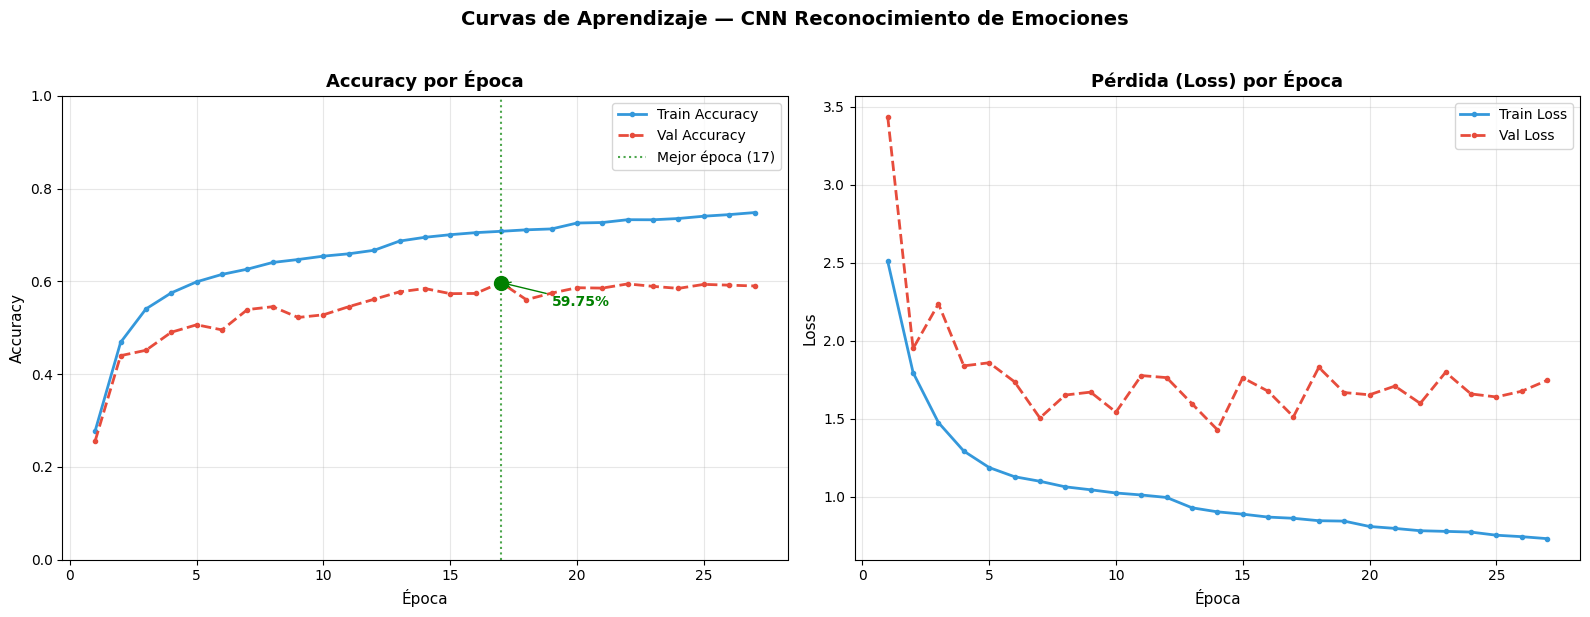

📊 Diagnóstico del entrenamiento:
   Épocas entrenadas: 27
   Mejor val_accuracy: 0.5975 (59.75%)
   Train accuracy final: 0.7483
   Val accuracy final:   0.5902

⚠️  POSIBLE OVERFITTING detectado
   Diferencia train-val: 15.82%
   Sugerencia: aumentar Dropout o más Data Augmentation


In [ ]:
# ============================================================
# CELDA 7 — VISUALIZACIÓN DE CURVAS DE APRENDIZAJE
# ============================================================
# Las curvas de aprendizaje nos muestran cómo evolucionó el
# modelo durante el entrenamiento época por época.
#
# ¿Qué debemos buscar?
#   ✅ BUEN MODELO: train y val convergen juntos hacia arriba
#   ❌ OVERFITTING: train sube, val se estanca o baja
#   ❌ UNDERFITTING: ambas son bajas y no suben
#
# Si hay overfitting, podemos:
#   - Aumentar el Dropout
#   - Reducir la complejidad del modelo
#   - Agregar más Data Augmentation

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ----------------------------------------------------------
# Extraemos los datos del historial de entrenamiento
# history.history es un diccionario con listas de valores
# por época para cada métrica
# ----------------------------------------------------------
train_acc  = history.history['accuracy']       # Accuracy en entrenamiento
val_acc    = history.history['val_accuracy']   # Accuracy en validación
train_loss = history.history['loss']           # Loss en entrenamiento
val_loss   = history.history['val_loss']       # Loss en validación
epochs_range = range(1, len(train_acc) + 1)   # Eje X: número de épocas

# ----------------------------------------------------------
# Creamos la figura con 2 gráficos lado a lado
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Curvas de Aprendizaje — CNN Reconocimiento de Emociones',
             fontsize=14, fontweight='bold', y=1.02)

# ── GRÁFICO 1: Accuracy ────────────────────────────────────
ax1 = axes[0]
ax1.plot(epochs_range, train_acc,
         label='Train Accuracy',
         color='#3498db',    # Azul
         linewidth=2,
         marker='o', markersize=3)
ax1.plot(epochs_range, val_acc,
         label='Val Accuracy',
         color='#e74c3c',    # Rojo
         linewidth=2,
         marker='o', markersize=3,
         linestyle='--')

# Marcamos el punto de mejor accuracy de validación
best_epoch_idx = val_acc.index(max(val_acc))
ax1.axvline(x=best_epoch_idx + 1,
            color='green', linestyle=':', alpha=0.7,
            label=f'Mejor época ({best_epoch_idx+1})')
ax1.scatter([best_epoch_idx + 1], [max(val_acc)],
            color='green', s=100, zorder=5)

ax1.set_title('Accuracy por Época', fontsize=13, fontweight='bold')
ax1.set_xlabel('Época', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_ylim(0, 1)
ax1.annotate(f'{max(val_acc):.2%}',
             xy=(best_epoch_idx + 1, max(val_acc)),
             xytext=(best_epoch_idx + 3, max(val_acc) - 0.05),
             fontsize=10, color='green', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='green'))

# ── GRÁFICO 2: Loss (Pérdida) ──────────────────────────────
ax2 = axes[1]
ax2.plot(epochs_range, train_loss,
         label='Train Loss',
         color='#3498db',
         linewidth=2,
         marker='o', markersize=3)
ax2.plot(epochs_range, val_loss,
         label='Val Loss',
         color='#e74c3c',
         linewidth=2,
         marker='o', markersize=3,
         linestyle='--')

ax2.set_title('Pérdida (Loss) por Época', fontsize=13, fontweight='bold')
ax2.set_xlabel('Época', fontsize=11)
ax2.set_ylabel('Loss', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# Diagnóstico automático del modelo
# ----------------------------------------------------------
print("📊 Diagnóstico del entrenamiento:")
print(f"   Épocas entrenadas: {len(train_acc)}")
print(f"   Mejor val_accuracy: {max(val_acc):.4f} ({max(val_acc)*100:.2f}%)")
print(f"   Train accuracy final: {train_acc[-1]:.4f}")
print(f"   Val accuracy final:   {val_acc[-1]:.4f}")

diferencia = train_acc[-1] - val_acc[-1]
if diferencia > 0.15:
    print(f"\n⚠️  POSIBLE OVERFITTING detectado")
    print(f"   Diferencia train-val: {diferencia:.2%}")
    print(f"   Sugerencia: aumentar Dropout o más Data Augmentation")
elif max(val_acc) < 0.50:
    print(f"\n⚠️  UNDERFITTING detectado")
    print(f"   El modelo no aprendió bien. Intenta más épocas o modelo más complejo")
else:
    print(f"\n✅ El modelo aprendió correctamente")
    print(f"   Diferencia train-val: {diferencia:.2%} (aceptable)")


8. Genera la matriz de confusión y reporte completo

📂 Cargando el mejor modelo guardado...


✅ Modelo cargado

🔄 Generando predicciones sobre el set de validación...
156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step

✅ Predicciones generadas: 9955 imágenes

📋 REPORTE DE CLASIFICACIÓN POR EMOCIÓN
              precision    recall  f1-score   support

       angry     0.4514    0.5532    0.4972      1184
     disgust     0.8937    0.1562    0.2660      1184
        fear     0.5033    0.3252    0.3951      1184
       happy     0.8414    0.8570    0.8491      2279
     neutral     0.5452    0.6461    0.5914      1633
         sad     0.3903    0.5539    0.4579      1307
    surprise     0.6974    0.8370    0.7608      1184

    accuracy                         0.5975      9955
   macro avg     0.6175    0.5612    0.5454      9955
weighted avg     0.6361    0.5975    0.5798      9955

🎯 Accuracy global: 0.5975 (59.75%)


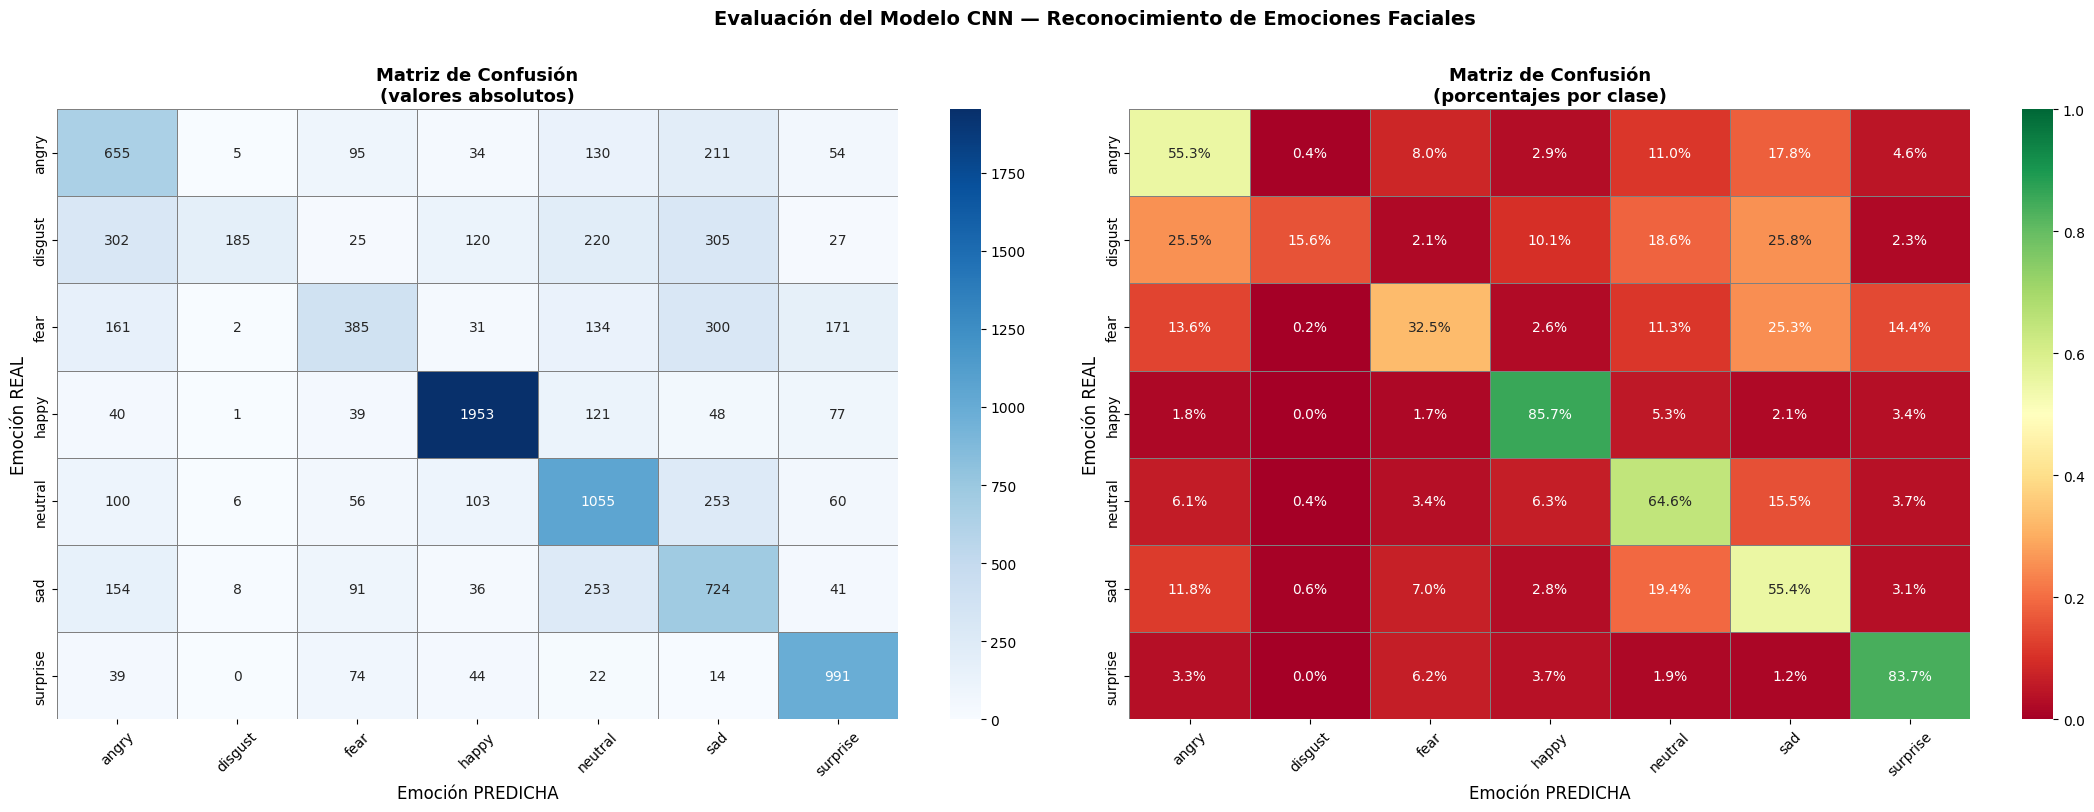


🔍 Confusiones más frecuentes (errores del modelo):
---------------------------------------------
   Real: disgust    → Predicho: sad         (305 veces)
   Real: disgust    → Predicho: angry       (302 veces)
   Real: fear       → Predicho: sad         (300 veces)
   Real: sad        → Predicho: neutral     (253 veces)
   Real: neutral    → Predicho: sad         (253 veces)
   Real: disgust    → Predicho: neutral     (220 veces)
   Real: angry      → Predicho: sad         (211 veces)
   Real: fear       → Predicho: surprise    (171 veces)


In [ ]:
# ============================================================
# CELDA 8 — EVALUACIÓN COMPLETA CON MATRIZ DE CONFUSIÓN
# ============================================================
# Evaluamos el modelo de forma detallada:
#
#   - Accuracy global: % total de predicciones correctas
#   - Precision: de todas las veces que predije "happy",
#                ¿cuántas realmente eran "happy"?
#   - Recall: de todas las imágenes realmente "happy",
#             ¿cuántas detecté correctamente?
#   - F1-score: media armónica entre precision y recall
#   - Matriz de confusión: qué emociones confunde el modelo
#
# La MATRIZ DE CONFUSIÓN es la herramienta más informativa:
# las filas son la emoción real, las columnas son la predicha.
# La diagonal principal son los aciertos.
# Los valores fuera de la diagonal son errores.

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

# ----------------------------------------------------------
# Paso 1: Cargamos el MEJOR modelo guardado durante el entrenamiento
# (puede ser diferente al modelo en memoria si EarlyStopping lo recuperó)
# ----------------------------------------------------------
print("📂 Cargando el mejor modelo guardado...")
best_model = tf.keras.models.load_model('best_emotion_cnn.h5')
print("✅ Modelo cargado")

# ----------------------------------------------------------
# Paso 2: Generar predicciones sobre TODO el set de validación
# Necesitamos reiniciar el generador para empezar desde el inicio
# ----------------------------------------------------------
print("\n🔄 Generando predicciones sobre el set de validación...")
val_gen.reset()   # Reinicia el generador al principio

# predict() devuelve probabilidades para cada clase
# Forma: (num_muestras, 7) — una fila por imagen, 7 columnas por emoción
y_pred_probs = best_model.predict(val_gen, verbose=1)

# argmax: tomamos el índice de la probabilidad más alta = clase predicha
y_pred = np.argmax(y_pred_probs, axis=1)  # Clase predicha (0-6)
y_true = val_gen.classes                   # Clase real de cada imagen

print(f"\n✅ Predicciones generadas: {len(y_pred)} imágenes")

# ----------------------------------------------------------
# Paso 3: Reporte de clasificación por clase
# Nos da métricas detalladas para cada emoción
# ----------------------------------------------------------
print("\n" + "="*65)
print("📋 REPORTE DE CLASIFICACIÓN POR EMOCIÓN")
print("="*65)
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,  # Nombres de las clases en lugar de números
    digits=4                   # 4 decimales de precisión
))

# ----------------------------------------------------------
# Paso 4: Accuracy global
# ----------------------------------------------------------
accuracy_global = np.mean(y_pred == y_true)
print(f"🎯 Accuracy global: {accuracy_global:.4f} ({accuracy_global*100:.2f}%)")

# ----------------------------------------------------------
# Paso 5: Matriz de confusión — absoluta y normalizada
# ----------------------------------------------------------

# Calculamos la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Versión normalizada: divide cada fila por el total de esa clase
# Así vemos el % de aciertos por clase, independiente del número de imágenes
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# ----------------------------------------------------------
# Graficamos ambas matrices lado a lado
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# ── Matriz ABSOLUTA (valores enteros) ─────────────────────
sns.heatmap(
    cm,
    annot=True,            # Muestra el número en cada celda
    fmt='d',               # Formato entero
    cmap='Blues',          # Escala de colores azules
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0],
    linewidths=0.5,
    linecolor='gray'
)
axes[0].set_title('Matriz de Confusión\n(valores absolutos)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Emoción REAL', fontsize=12)
axes[0].set_xlabel('Emoción PREDICHA', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# ── Matriz NORMALIZADA (porcentajes) ──────────────────────
sns.heatmap(
    cm_norm,
    annot=True,            # Muestra el % en cada celda
    fmt='.1%',             # Formato de porcentaje con 1 decimal
    cmap='RdYlGn',         # Rojo (mal) → Amarillo → Verde (bien)
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1],
    linewidths=0.5,
    linecolor='gray',
    vmin=0, vmax=1         # Escala de 0% a 100%
)
axes[1].set_title('Matriz de Confusión\n(porcentajes por clase)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Emoción REAL', fontsize=12)
axes[1].set_xlabel('Emoción PREDICHA', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Evaluación del Modelo CNN — Reconocimiento de Emociones Faciales',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# Paso 6: Análisis de las confusiones más frecuentes
# (qué pares de emociones confunde más el modelo)
# ----------------------------------------------------------
print("\n🔍 Confusiones más frecuentes (errores del modelo):")
print("-" * 45)
# Creamos una copia sin la diagonal (sin los aciertos) para ver solo errores
cm_sin_diagonal = cm.copy()
np.fill_diagonal(cm_sin_diagonal, 0)  # Los aciertos no nos interesan aquí

# Ordenamos los errores de mayor a menor
errores = []
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if i != j and cm_sin_diagonal[i, j] > 0:
            errores.append((cm_sin_diagonal[i, j], CLASS_NAMES[i], CLASS_NAMES[j]))

errores.sort(reverse=True)  # Los errores más frecuentes primero

for cantidad, real, predicho in errores[:8]:  # Mostramos los 8 más frecuentes
    print(f"   Real: {real:10s} → Predicho: {predicho:10s}  ({int(cantidad)} veces)")


9. Transfer Learning con MobileNetV2 (modelo mejorado)

In [ ]:
# ============================================================
# CELDA 9 — TRANSFER LEARNING CON MobileNetV2 (MODELO MEJORADO)
# ============================================================
# Transfer Learning = usar un modelo ya entrenado para otra tarea
# y adaptarlo a nuestra tarea específica.
#
# ¿Por qué funciona?
# MobileNetV2 fue entrenado con MILLONES de imágenes (ImageNet).
# Ya sabe detectar bordes, texturas, formas, objetos...
# Nosotros solo necesitamos enseñarle la ÚLTIMA PARTE:
# cómo clasificar esas features en emociones.
#
# Proceso en 2 fases:
#   FASE 1: Congelamos MobileNetV2, entrenamos solo nuestra cabeza
#   FASE 2: Descongelamos las últimas capas (fine-tuning) con LR muy bajo
#
# Resultado esperado: mejor accuracy que la CNN desde cero

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

# ----------------------------------------------------------
# CONFIGURACIÓN para Transfer Learning
# MobileNetV2 trabaja mejor con imágenes más grandes (96x96)
# y necesita 3 canales (RGB), aunque nuestras imágenes sean grises
# ----------------------------------------------------------
IMG_SIZE_TL = (96, 96)  # Tamaño mayor que el CNN desde cero
BATCH_SIZE  = 64
SEED        = 42
data_dir    = '/content/data/processed_data'

# ----------------------------------------------------------
# Re-creamos los generadores con color_mode='rgb'
# (MobileNetV2 espera 3 canales, aunque la imagen sea gris
# simplemente replica el canal gris en R, G y B)
# ----------------------------------------------------------
train_datagen_tl = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

val_datagen_tl = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Generador de entrenamiento en RGB
train_gen_tl = train_datagen_tl.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE_TL,   # 96x96 para MobileNetV2
    color_mode='rgb',           # 3 canales (requerido por MobileNetV2)
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

# Generador de validación en RGB
val_gen_tl = val_datagen_tl.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE_TL,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print(f"✅ Generadores RGB creados")
print(f"   Imágenes de entrenamiento: {train_gen_tl.samples}")
print(f"   Imágenes de validación:    {val_gen_tl.samples}")

# ----------------------------------------------------------
# Cargamos MobileNetV2 preentrenado
# include_top=False → excluimos la capa final de clasificación
#                     de ImageNet (1000 clases) que no necesitamos
# weights='imagenet' → usamos los pesos preentrenados
# ----------------------------------------------------------
print("\n📥 Descargando MobileNetV2 con pesos de ImageNet...")
base_model = MobileNetV2(
    input_shape=(96, 96, 3),  # Tamaño de entrada
    include_top=False,         # Sin la cabeza clasificadora original
    weights='imagenet'         # Pesos preentrenados en 1.2 millones de imágenes
)

# CONGELAMOS todas las capas del modelo base
# No queremos que cambien durante la fase 1 del entrenamiento
base_model.trainable = False

print(f"✅ MobileNetV2 cargado ({len(base_model.layers)} capas congeladas)")

# ----------------------------------------------------------
# Construimos nuestro modelo completo:
# MobileNetV2 (extractor de features) + Nuestra cabeza (clasificador)
# ----------------------------------------------------------
inputs = tf.keras.Input(shape=(96, 96, 3))

# Pasamos las imágenes por MobileNetV2 para extraer features
# training=False → MobileNetV2 no actualiza BatchNorm durante entrenamiento
x = base_model(inputs, training=False)

# GlobalAveragePooling agrupa todos los features en un vector
x = layers.GlobalAveragePooling2D()(x)

# Nuestra cabeza de clasificación personalizada
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)

# Capa de salida: 7 emociones
outputs = layers.Dense(7, activation='softmax')(x)

# Modelo completo
tl_model = tf.keras.Model(inputs, outputs, name='MobileNetV2_Emociones')

# Compilamos para la Fase 1 (solo entrenamos la cabeza)
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n📋 Arquitectura del modelo Transfer Learning:")
print(f"   Parámetros totales:      {tl_model.count_params():,}")
print(f"   Parámetros entrenables:  {sum([tf.size(w).numpy() for w in tl_model.trainable_weights]):,}")
print(f"   Parámetros congelados:   {sum([tf.size(w).numpy() for w in tl_model.non_trainable_weights]):,}")

# ══════════════════════════════════════════════════════════════
# FASE 1: Entrenamos SOLO la cabeza de clasificación
# Las capas de MobileNetV2 están congeladas → no cambian
# Esta fase va rápido porque solo hay pocos parámetros que aprender
# ══════════════════════════════════════════════════════════════
print("\n🔵 FASE 1: Entrenando la cabeza de clasificación...")
print("   (MobileNetV2 congelado — solo aprendemos el clasificador)")

history_fase1 = tl_model.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=15,                      # Pocas épocas, la cabeza converge rápido
    class_weight=class_weight_dict, # Compensar desbalance
    callbacks=[
        EarlyStopping(
            patience=5,
            restore_best_weights=True,
            monitor='val_accuracy',
            verbose=1
        )
    ],
    verbose=1
)

print(f"\n✅ Fase 1 completada")
print(f"   Mejor val_accuracy: {max(history_fase1.history['val_accuracy']):.4f}")

# ══════════════════════════════════════════════════════════════
# FASE 2: Fine-tuning — descongelamos las últimas capas de MobileNetV2
# Ahora ajustamos TAMBIÉN las capas superiores de MobileNetV2
# para que se adapten mejor a imágenes de rostros.
# IMPORTANTE: usamos un learning rate MUY BAJO para no destruir
# el conocimiento preentrenado.
# ══════════════════════════════════════════════════════════════
print("\n🟠 FASE 2: Fine-tuning — descongelando capas superiores...")
print("   (Las últimas 54 capas de MobileNetV2 ahora son entrenables)")

# Descongelamos el modelo base
base_model.trainable = True

# Congelamos las primeras 100 capas (detectan features muy básicos como bordes)
# Solo descongelamos las capas superiores que detectan features más específicos
for layer in base_model.layers[:100]:
    layer.trainable = False  # Seguimos congelando las primeras 100

capas_entrenables = sum(1 for l in base_model.layers if l.trainable)
print(f"   Capas de MobileNetV2 descongeladas: {capas_entrenables}")

# Recompilamos con learning rate MUY pequeño para fine-tuning
# Si usamos un LR grande, destruiríamos los pesos preentrenados
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 100x más pequeño
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Guardamos el mejor modelo de MobileNetV2
checkpoint_tl = ModelCheckpoint(
    'best_emotion_mobilenet.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_fase2 = tl_model.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=25,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(patience=8, restore_best_weights=True,
                      monitor='val_accuracy', verbose=1),
        ReduceLROnPlateau(patience=4, factor=0.5,
                          min_lr=1e-8, verbose=1),
        checkpoint_tl
    ],
    verbose=1
)

# ----------------------------------------------------------
# Comparación final entre CNN desde cero y MobileNetV2
# ----------------------------------------------------------
print("\n" + "="*50)
print("📊 COMPARACIÓN DE MODELOS")
print("="*50)
print(f"   CNN desde cero:    {max(history.history['val_accuracy']):.4f} ({max(history.history['val_accuracy'])*100:.2f}%)")
print(f"   MobileNetV2:       {max(history_fase2.history['val_accuracy']):.4f} ({max(history_fase2.history['val_accuracy'])*100:.2f}%)")
print("\n✅ Ambos modelos han sido guardados en .h5")


Found 39824 images belonging to 7 classes.
Found 9955 images belonging to 7 classes.
✅ Generadores RGB creados
   Imágenes de entrenamiento: 39824
   Imágenes de validación:    9955

📥 Descargando MobileNetV2 con pesos de ImageNet...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ MobileNetV2 cargado (154 capas congeladas)

📋 Arquitectura del modelo Transfer Learning:
   Parámetros totales:      3,049,031
   Parámetros entrenables:  790,023
   Parámetros congelados:   2,259,008

🔵 FASE 1: Entrenando la cabeza de clasificación...
   (MobileNetV2 congelado — solo aprendemos el clasificador)
Epoch 1/15
623/623 ━━━━━━━━━━━━━━━━━━━━ 165s 235ms/step - accuracy: 0.4143 - loss: 1.5560 - val_accuracy: 0.3672 - val_loss: 1.9604
Epoch 2/15
623/623 ━━━━━━━━━━━━━━━━━━━━ 119s 192ms/step - accuracy: 0.4762 - loss: 1.3273 - val_accuracy: 0.3942 - val_loss: 1.9019
Epoch 3/15
623/623 ━━━━━━━━━━━━━━━━━━━━ 119s 191ms/step - accuracy: 0.4963 - loss: 1.2824 - val_accuracy: 0.4145 - val_loss: 2.0487
Epoch


Epoch 1: finished saving model to best_emotion_mobilenet.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 168s 230ms/step - accuracy: 0.4227 - loss: 1.5160 - val_accuracy: 0.4172 - val_loss: 3.4146 - learning_rate: 1.0000e-05
Epoch 2/25
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.4767 - loss: 1.3610
Epoch 2: val_accuracy improved from 0.41718 to 0.43024, saving model to best_emotion_mobilenet.h5



Epoch 2: finished saving model to best_emotion_mobilenet.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 123s 198ms/step - accuracy: 0.4837 - loss: 1.3400 - val_accuracy: 0.4302 - val_loss: 2.6710 - learning_rate: 1.0000e-05
Epoch 3/25
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.5056 - loss: 1.2737
Epoch 3: val_accuracy improved from 0.43024 to 0.44229, saving model to best_emotion_mobilenet.h5



Epoch 3: finished saving model to best_emotion_mobilenet.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 130s 208ms/step - accuracy: 0.5104 - loss: 1.2681 - val_accuracy: 0.4423 - val_loss: 2.5092 - learning_rate: 1.0000e-05
Epoch 4/25
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.5234 - loss: 1.2316
Epoch 4: val_accuracy improved from 0.44229 to 0.44842, saving model to best_emotion_mobilenet.h5



Epoch 4: finished saving model to best_emotion_mobilenet.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 126s 202ms/step - accuracy: 0.5307 - loss: 1.2200 - val_accuracy: 0.4484 - val_loss: 2.4822 - learning_rate: 1.0000e-05
Epoch 5/25
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.5407 - loss: 1.1904
Epoch 5: val_accuracy improved from 0.44842 to 0.45907, saving model to best_emotion_mobilenet.h5


...


Epoch 17: finished saving model to best_emotion_mobilenet.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 126s 202ms/step - accuracy: 0.6153 - loss: 1.0201 - val_accuracy: 0.4959 - val_loss: 2.3991 - learning_rate: 5.0000e-06
Epoch 18/25
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.6185 - loss: 1.0079
Epoch 18: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.

Epoch 18: val_accuracy improved from 0.49593 to 0.49965, saving model to best_emotion_mobilenet.h5



Epoch 18: finished saving model to best_emotion_mobilenet.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 127s 204ms/step - accuracy: 0.6181 - loss: 1.0110 - val_accuracy: 0.4996 - val_loss: 2.4040 - learning_rate: 5.0000e-06
Epoch 19/25
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.6238 - loss: 1.0021
Epoch 19: val_accuracy did not improve from 0.49965
623/623 ━━━━━━━━━━━━━━━━━━━━ 118s 189ms/step - accuracy: 0.6237 - loss: 1.0029 - val_accuracy: 0.4977 - val_loss: 2.4030 - learning_rate: 2.5000e-06
Epoch 20/25
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.6269 - loss: 0.9940
Epoch 20: val_accuracy did not improve from 0.49965
623/623 ━━━━━━━━━━━━━━━━━━━━ 119s 190ms/step - accuracy: 0.6240 - loss: 0.9972 - val_accuracy: 0.4969 - val_loss: 2.4113 - learning_rate: 2.5000e-06
Epoch 21/25
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.6292 - loss: 0.9974
Epoch 21: val_accuracy improved from 0.49965 to 0.50065, saving model to best_emotion_mobilenet.h5



Epoch 21: finished saving model to best_emotion_mobilenet.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 122s 195ms/step - accuracy: 0.6255 - loss: 1.0001 - val_accuracy: 0.5007 - val_loss: 2.4026 - learning_rate: 2.5000e-06
Epoch 22/25
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.6283 - loss: 0.9869
Epoch 22: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-06.

Epoch 22: val_accuracy improved from 0.50065 to 0.50156, saving model to best_emotion_mobilenet.h5



Epoch 22: finished saving model to best_emotion_mobilenet.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 127s 204ms/step - accuracy: 0.6269 - loss: 0.9904 - val_accuracy: 0.5016 - val_loss: 2.4197 - learning_rate: 2.5000e-06
Epoch 23/25
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.6295 - loss: 0.9911
Epoch 23: val_accuracy did not improve from 0.50156
623/623 ━━━━━━━━━━━━━━━━━━━━ 124s 200ms/step - accuracy: 0.6276 - loss: 0.9885 - val_accuracy: 0.5012 - val_loss: 2.4195 - learning_rate: 1.2500e-06
Epoch 24/25
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6280 - loss: 0.9927
Epoch 24: val_accuracy did not improve from 0.50156
623/623 ━━━━━━━━━━━━━━━━━━━━ 122s 196ms/step - accuracy: 0.6271 - loss: 0.9853 - val_accuracy: 0.5006 - val_loss: 2.4274 - learning_rate: 1.2500e-06
Epoch 25/25
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.6287 - loss: 0.9939
Epoch 25: val_accuracy improved from 0.50156 to 0.50266, saving model to best_emotion_mobilenet.h5



Epoch 25: finished saving model to best_emotion_mobilenet.h5
623/623 ━━━━━━━━━━━━━━━━━━━━ 126s 202ms/step - accuracy: 0.6300 - loss: 0.9852 - val_accuracy: 0.5027 - val_loss: 2.4190 - learning_rate: 1.2500e-06
Restoring model weights from the end of the best epoch: 25.

📊 COMPARACIÓN DE MODELOS
   CNN desde cero:    0.5975 (59.75%)
   MobileNetV2:       0.5027 (50.27%)

✅ Ambos modelos han sido guardados en .h5


10. Muestra predicciones visuales con barras de confianza

📂 Cargando el mejor modelo CNN...


✅ Modelo listo para predecir


/tmp/ipykernel_11276/665522093.py:191: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11276/665522093.py:191: UserWarning: Glyph 129314 (\N{NAUSEATED FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11276/665522093.py:192: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('predicciones_ejemplo.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_11276/665522093.py:192: UserWarning: Glyph 129314 (\N{NAUSEATED FACE}) missing from font(s) DejaVu Sans.
  plt.savefig('predicciones_ejemplo.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129314 (\N{NAUSEATED FACE}) mi

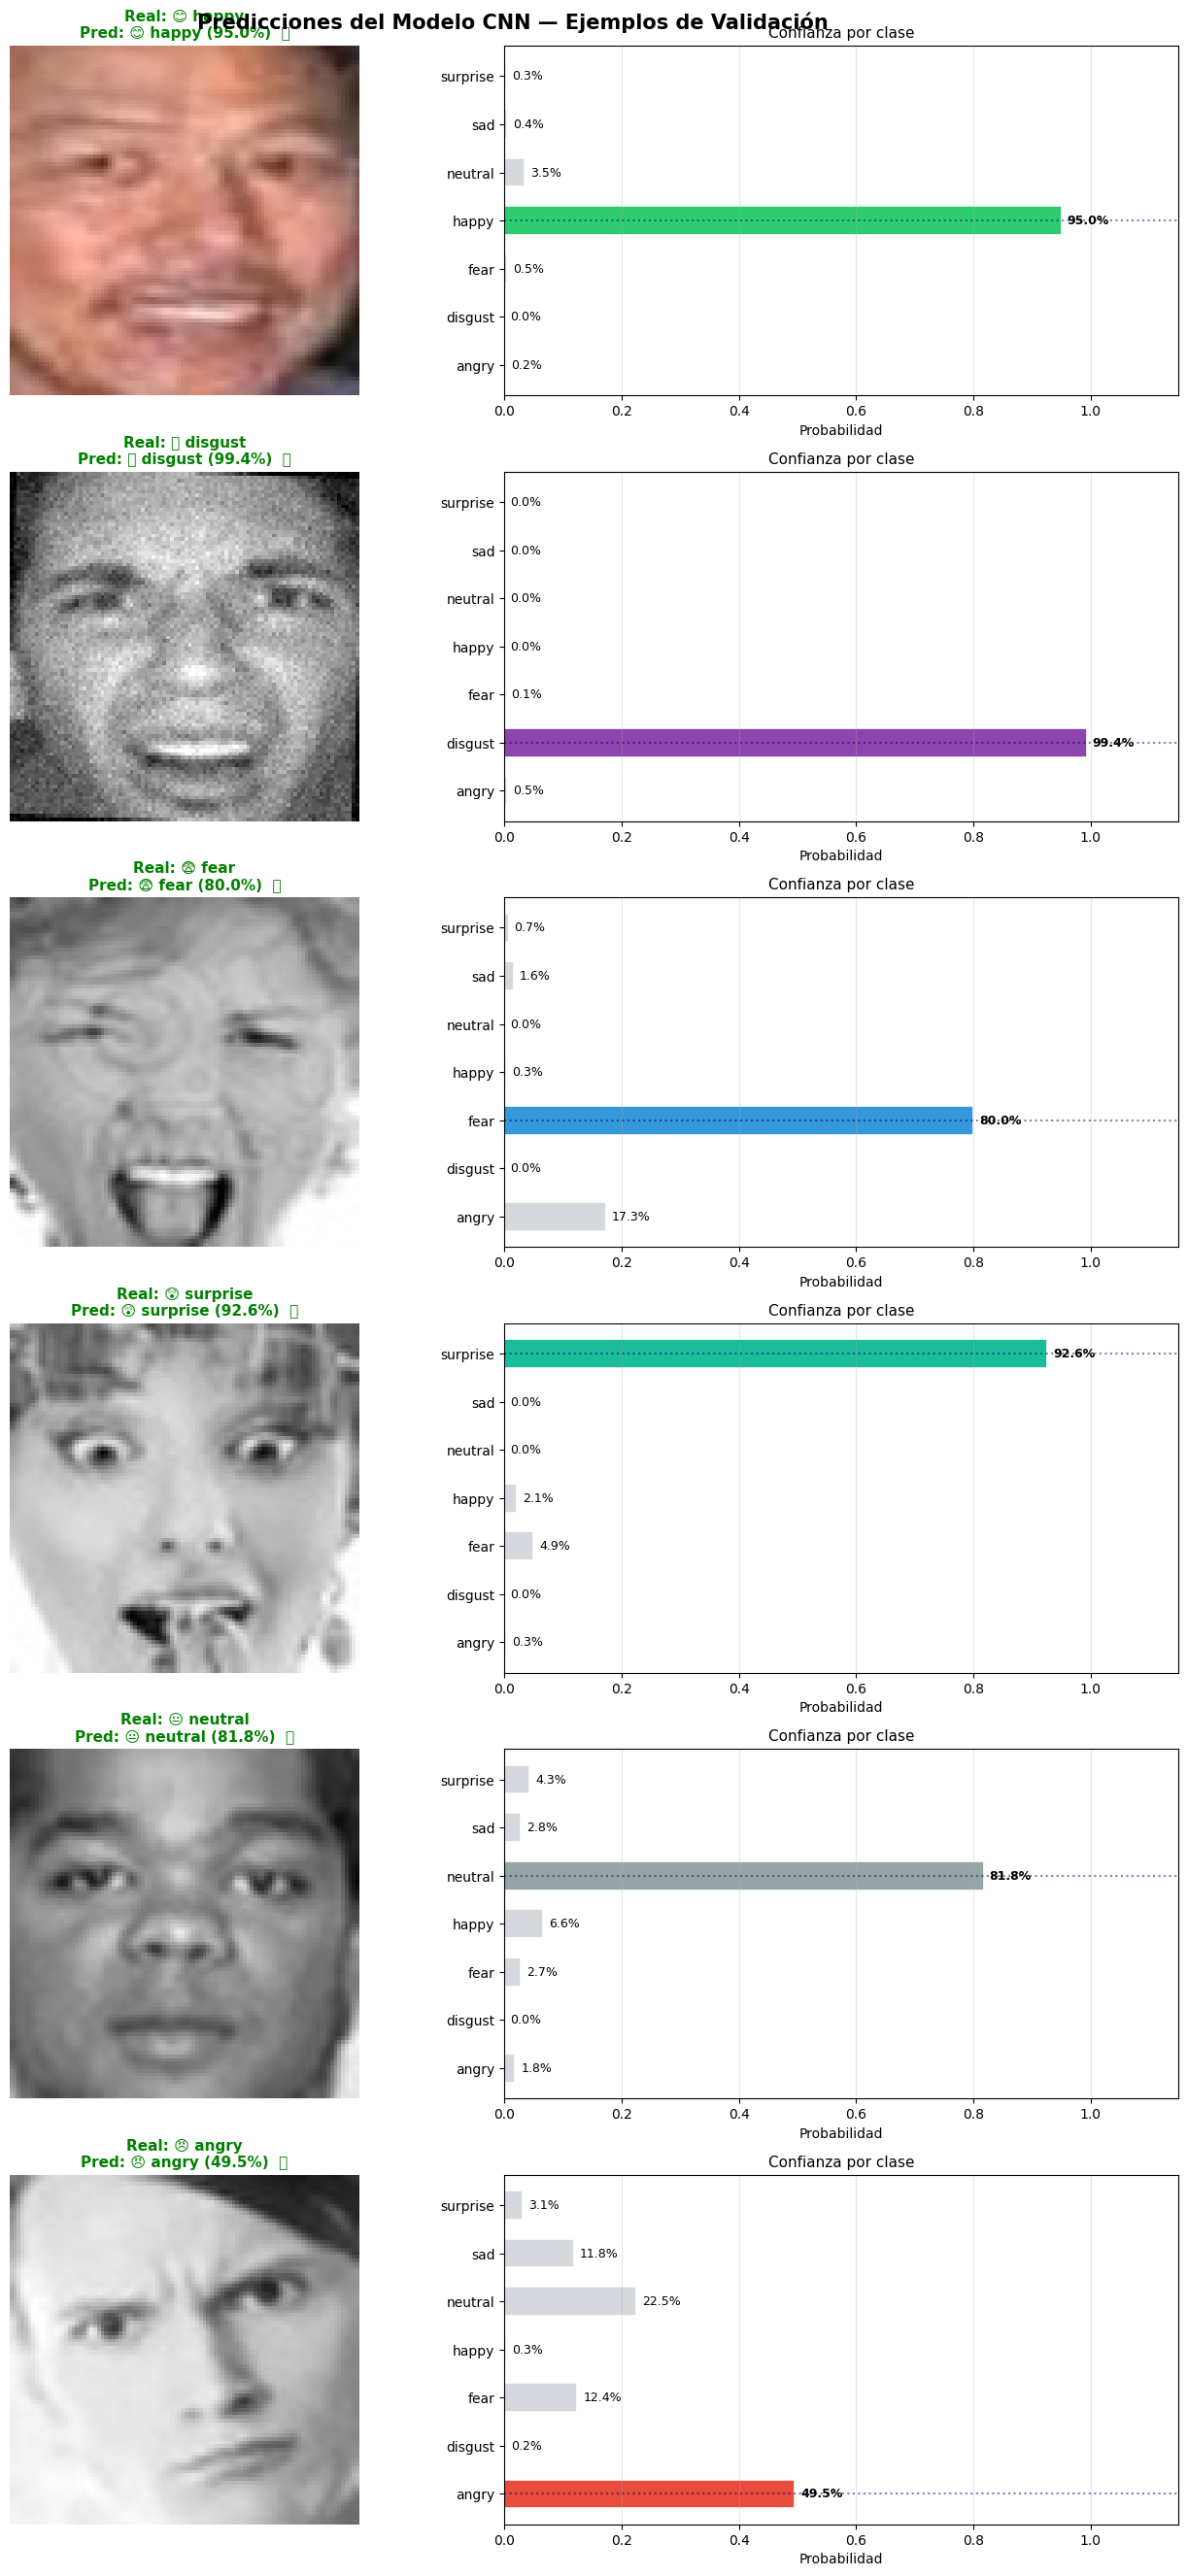


🎯 Aciertos en la muestra: 6/6 (100%)
   (Esto es solo una muestra, el accuracy real está en la Celda 8)


In [ ]:
# ============================================================
# CELDA 10 — PREDICCIÓN EN IMÁGENES DE EJEMPLO
# ============================================================
# Probamos el modelo visualmente con imágenes del dataset.
# Para cada imagen mostramos:
#   - La imagen original
#   - La emoción real
#   - La emoción predicha y la confianza
#   - Un gráfico de barras con las probabilidades de todas las clases
#
# Esto nos permite entender intuitivamente cómo "piensa" el modelo

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import random
import os

# ----------------------------------------------------------
# Función reutilizable para predecir la emoción de una imagen
# ----------------------------------------------------------
def predecir_emocion(ruta_imagen, modelo, class_names,
                      img_size=(48, 48), color_mode='grayscale'):
    """
    Carga una imagen, la preprocesa exactamente igual que en el entrenamiento
    y predice qué emoción tiene.

    Args:
        ruta_imagen : str   — ruta completa al archivo de imagen
        modelo      : Model — modelo de Keras entrenado
        class_names : list  — lista de nombres de clases en orden
        img_size    : tuple — (alto, ancho) de entrada del modelo
        color_mode  : str   — 'grayscale' para CNN, 'rgb' para MobileNetV2

    Returns:
        emocion     : str   — nombre de la emoción predicha
        confianza   : float — probabilidad de esa predicción (0 a 1)
        probs       : array — probabilidades de todas las clases
    """

    # Paso 1: Cargar la imagen y redimensionarla al tamaño del modelo
    img = image.load_img(
        ruta_imagen,
        target_size=img_size,    # Redimensionamos a 48x48 o 96x96
        color_mode=color_mode    # Escala de grises o RGB
    )

    # Paso 2: Convertir a array numpy y normalizar a [0, 1]
    img_array = image.img_to_array(img) / 255.0

    # Paso 3: Añadir dimensión de batch
    # El modelo espera entrada de forma (batch, alto, ancho, canales)
    # Nuestra imagen tiene forma (alto, ancho, canales)
    # np.expand_dims añade el batch → (1, alto, ancho, canales)
    img_array = np.expand_dims(img_array, axis=0)

    # Paso 4: Hacer la predicción
    # probs es un array de 7 valores que suman 1.0
    # Ejemplo: [0.02, 0.01, 0.05, 0.85, 0.03, 0.02, 0.02]
    probs = modelo.predict(img_array, verbose=0)[0]

    # Paso 5: Encontrar la clase con mayor probabilidad
    idx_predicho = np.argmax(probs)         # Índice de la probabilidad más alta
    emocion = class_names[idx_predicho]     # Nombre de esa clase
    confianza = probs[idx_predicho]         # Probabilidad de esa clase

    return emocion, confianza, probs


# ----------------------------------------------------------
# Configuración visual
#Angry (enojo): emoción negativa de irritación o enfado.
#Disgust (rechazo): emoción de repulsión que lleva a evitar algo desagradable.
#Fear (miedo): respuesta emocional ante una amenaza o peligro.
#Happy (felicidad): emoción positiva de alegría o bienestar.
#Neutral (neutral): ausencia de emoción evidente.
#Sad (tristeza): estado emocional de pena o desánimo.
#Surprise (sorpresa): reacción ante algo inesperado.
# ----------------------------------------------------------
emoji_map = {
    'angry': '😠', 'disgust': '🤢', 'fear': '😨',
    'happy': '😊', 'neutral': '😐', 'sad': '😢', 'surprise': '😲'
}

# Color para cada emoción en el gráfico de barras
colores_emociones = {
    'angry': '#e74c3c',   'disgust': '#8e44ad',
    'fear': '#3498db',    'happy': '#2ecc71',
    'neutral': '#95a5a6', 'sad': '#f39c12',
    'surprise': '#1abc9c'
}

data_dir = '/content/data/processed_data'

# ----------------------------------------------------------
# Cargamos el mejor modelo CNN entrenado
# ----------------------------------------------------------
print("📂 Cargando el mejor modelo CNN...")
mejor_modelo = tf.keras.models.load_model('best_emotion_cnn.h5')
print("✅ Modelo listo para predecir")

# ----------------------------------------------------------
# Seleccionamos 6 imágenes aleatorias de diferentes emociones
# para tener una muestra variada
# ----------------------------------------------------------
clases_muestra = random.sample(CLASS_NAMES, min(6, len(CLASS_NAMES)))
imagenes_prueba = []

for clase in clases_muestra:
    carpeta = os.path.join(data_dir, clase)
    imagen = random.choice(os.listdir(carpeta))
    ruta = os.path.join(carpeta, imagen)
    imagenes_prueba.append((ruta, clase))

# ----------------------------------------------------------
# Graficamos: imagen + barras de probabilidad para cada ejemplo
# ----------------------------------------------------------
n = len(imagenes_prueba)
fig, axes = plt.subplots(n, 2, figsize=(14, 4.5 * n))
fig.suptitle('Predicciones del Modelo CNN — Ejemplos de Validación',
             fontsize=15, fontweight='bold')

aciertos = 0

for idx, (ruta, emocion_real) in enumerate(imagenes_prueba):

    # Hacemos la predicción
    emocion_pred, confianza, probs = predecir_emocion(
        ruta, mejor_modelo, CLASS_NAMES,
        img_size=(48, 48), color_mode='grayscale'
    )

    # ¿Acertó o no?
    correcto = emocion_pred == emocion_real
    if correcto:
        aciertos += 1
    icono = '✅' if correcto else '❌'
    color_titulo = 'green' if correcto else 'red'

    # ── Columna izquierda: imagen original ────────────────
    img_display = plt.imread(ruta)
    axes[idx, 0].imshow(img_display, cmap='gray')
    axes[idx, 0].set_title(
        f'Real: {emoji_map[emocion_real]} {emocion_real}\n'
        f'Pred: {emoji_map[emocion_pred]} {emocion_pred} '
        f'({confianza:.1%})  {icono}',
        fontsize=11,
        color=color_titulo,
        fontweight='bold'
    )
    axes[idx, 0].axis('off')  # Ocultamos los ejes de la imagen

    # ── Columna derecha: gráfico de probabilidades ────────
    # Color resaltado para la barra predicha, gris para las demás
    colores_barras = [
        colores_emociones[c] if c == emocion_pred else '#d5d8dc'
        for c in CLASS_NAMES
    ]
    bars = axes[idx, 1].barh(
        CLASS_NAMES, probs,
        color=colores_barras,
        edgecolor='white',
        linewidth=1.2,
        height=0.6
    )

    # Añadimos el porcentaje al final de cada barra
    for bar, prob in zip(bars, probs):
        axes[idx, 1].text(
            prob + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{prob:.1%}',
            va='center', fontsize=9,
            fontweight='bold' if prob == max(probs) else 'normal'
        )

    axes[idx, 1].set_xlim(0, 1.15)
    axes[idx, 1].set_xlabel('Probabilidad', fontsize=10)
    axes[idx, 1].set_title('Confianza por clase', fontsize=11)
    axes[idx, 1].grid(axis='x', alpha=0.3)

    # Marcamos con línea la emoción real
    idx_real = CLASS_NAMES.index(emocion_real)
    axes[idx, 1].axhline(
        y=idx_real, color='navy',
        linestyle=':', alpha=0.5, linewidth=1.5
    )

plt.tight_layout()
plt.savefig('predicciones_ejemplo.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# Resumen de aciertos en esta muestra
# ----------------------------------------------------------
print(f"\n🎯 Aciertos en la muestra: {aciertos}/{n} ({aciertos/n:.0%})")
print("   (Esto es solo una muestra, el accuracy real está en la Celda 8)")


11. Guarda y descarga el modelo a tu PC

In [ ]:
# ============================================================
# CELDA 11 — GUARDAR Y DESCARGAR EL MODELO FINAL
# ============================================================
# Guardamos todo lo necesario para usar el modelo después:
#   - El modelo entrenado (.h5) → la "inteligencia" del sistema
#   - Los nombres de las clases (.json) → para interpretar la salida
#   - Las gráficas generadas (.png) → para el reporte
#
# En Google Colab los archivos se BORRAN cuando cierras la sesión.
# Por eso es IMPORTANTE descargarlos a tu PC.

import tensorflow as tf
import json
import os
from google.colab import files  # Para descargar archivos a tu PC

# ----------------------------------------------------------
# Paso 1: Guardar el modelo CNN desde cero
# formato .h5 es compatible con Keras y TensorFlow
# ----------------------------------------------------------
print("💾 Guardando modelos...")

# Guardamos el mejor modelo CNN (ya fue guardado por ModelCheckpoint,
# pero lo guardamos de nuevo con nombre más descriptivo)
mejor_modelo_cnn = tf.keras.models.load_model('best_emotion_cnn.h5')
mejor_modelo_cnn.save('emotion_cnn_final.h5')
print("   ✅ emotion_cnn_final.h5 — CNN desde cero")

# Si entrenaste el Transfer Learning (Celda 9):
if os.path.exists('best_emotion_mobilenet.h5'):
    mejor_modelo_tl = tf.keras.models.load_model('best_emotion_mobilenet.h5')
    mejor_modelo_tl.save('emotion_mobilenet_final.h5')
    print("   ✅ emotion_mobilenet_final.h5 — MobileNetV2 fine-tuned")

# ----------------------------------------------------------
# Paso 2: Guardar el mapeo de clases en JSON
# ESTE ARCHIVO ES IMPRESCINDIBLE para hacer predicciones después.
# Sin él, el modelo devuelve números (0-6) y no sabemos
# a qué emoción corresponde cada número.
# ----------------------------------------------------------
with open('class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)
print("   ✅ class_names.json — mapeo de índices a nombres de emoción")

# Verificamos el contenido del JSON
with open('class_names.json', 'r') as f:
    clases_guardadas = json.load(f)
print(f"\n📋 Clases guardadas en JSON:")
for idx, nombre in enumerate(clases_guardadas):
    print(f"   {idx} → {nombre}")

# ----------------------------------------------------------
# Paso 3: Guardar métricas finales en un archivo de texto
# ----------------------------------------------------------
with open('metricas_finales.txt', 'w') as f:
    f.write("RESULTADOS DEL ENTRENAMIENTO\n")
    f.write("="*40 + "\n\n")
    f.write(f"Mejor val_accuracy (CNN): {max(history.history['val_accuracy']):.4f}\n")
    f.write(f"Épocas entrenadas:        {len(history.history['val_accuracy'])}\n")
    f.write(f"Clases: {CLASS_NAMES}\n")
print("   ✅ metricas_finales.txt")

# ----------------------------------------------------------
# Paso 4: Descargar todos los archivos a tu PC
# Aparecerá la descarga automáticamente en el navegador
# ----------------------------------------------------------
print("\n📥 Descargando archivos a tu PC...")
print("   (Si no se descarga automáticamente, haz clic en el archivo)")

archivos = [
    ('emotion_cnn_final.h5',       '⭐ Modelo CNN principal'),
    ('emotion_mobilenet_final.h5', '⭐ Modelo MobileNetV2 (si lo entrenaste)'),
    ('class_names.json',           '📋 Mapeo de clases (necesario para predecir)'),
    ('metricas_finales.txt',       '📊 Métricas del entrenamiento'),
    ('curvas_aprendizaje.png',     '📈 Gráfica de entrenamiento'),
    ('matriz_confusion.png',       '🔵 Matriz de confusión'),
    ('predicciones_ejemplo.png',   '🖼️  Ejemplos de predicciones'),
]

for nombre_archivo, descripcion in archivos:
    if os.path.exists(nombre_archivo):
        print(f"\n   ⬇️  Descargando: {nombre_archivo}  ({descripcion})")
        files.download(nombre_archivo)
    else:
        print(f"\n   ⚠️  No encontrado: {nombre_archivo} — (puede que no se haya generado)")

print("\n✅ Descarga completada!")
print("\n📌 CÓMO USAR EL MODELO EN EL FUTURO:")
print("   1. Carga el modelo:   model = tf.keras.models.load_model('emotion_cnn_final.h5')")
print("   2. Carga las clases:  import json; classes = json.load(open('class_names.json'))")
print("   3. Preprocesa imagen: img = image.load_img(ruta, target_size=(48,48), color_mode='grayscale')")
print("   4. Normaliza:         arr = image.img_to_array(img) / 255.0")
print("   5. Predice:           probs = model.predict(arr[np.newaxis,...])[0]")
print("   6. Interpreta:        emocion = classes[np.argmax(probs)]")


💾 Guardando modelos...


   ✅ emotion_cnn_final.h5 — CNN desde cero


   ✅ emotion_mobilenet_final.h5 — MobileNetV2 fine-tuned
   ✅ class_names.json — mapeo de índices a nombres de emoción

📋 Clases guardadas en JSON:
   0 → angry
   1 → disgust
   2 → fear
   3 → happy
   4 → neutral
   5 → sad
   6 → surprise
   ✅ metricas_finales.txt

📥 Descargando archivos a tu PC...
   (Si no se descarga automáticamente, haz clic en el archivo)

   ⬇️  Descargando: emotion_cnn_final.h5  (⭐ Modelo CNN principal)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>


   ⬇️  Descargando: predicciones_ejemplo.png  (🖼️  Ejemplos de predicciones)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Descarga completada!

📌 CÓMO USAR EL MODELO EN EL FUTURO:
   1. Carga el modelo:   model = tf.keras.models.load_model('emotion_cnn_final.h5')
   2. Carga las clases:  import json; classes = json.load(open('class_names.json'))
   3. Preprocesa imagen: img = image.load_img(ruta, target_size=(48,48), color_mode='grayscale')
   4. Normaliza:         arr = image.img_to_array(img) / 255.0
   5. Predice:           probs = model.predict(arr[np.newaxis,...])[0]
   6. Interpreta:        emocion = classes[np.argmax(probs)]


12. Sube tu propia foto y predice tu emoción

📂 Cargando modelo y clases...


✅ Modelo listo. Clases: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

📸 Sube una foto con un rostro visible...
   (JPG, PNG, o JPEG — se convertirá automáticamente a escala de grises)


Saving WhatsApp Image 2026-04-07 at 9.01.13 AM.jpeg to WhatsApp Image 2026-04-07 at 9.01.13 AM.jpeg
Saving WhatsApp Image 2026-04-07 at 9.01.12 AM.jpeg to WhatsApp Image 2026-04-07 at 9.01.12 AM.jpeg

🔍 Procesando: WhatsApp Image 2026-04-07 at 9.01.13 AM.jpeg


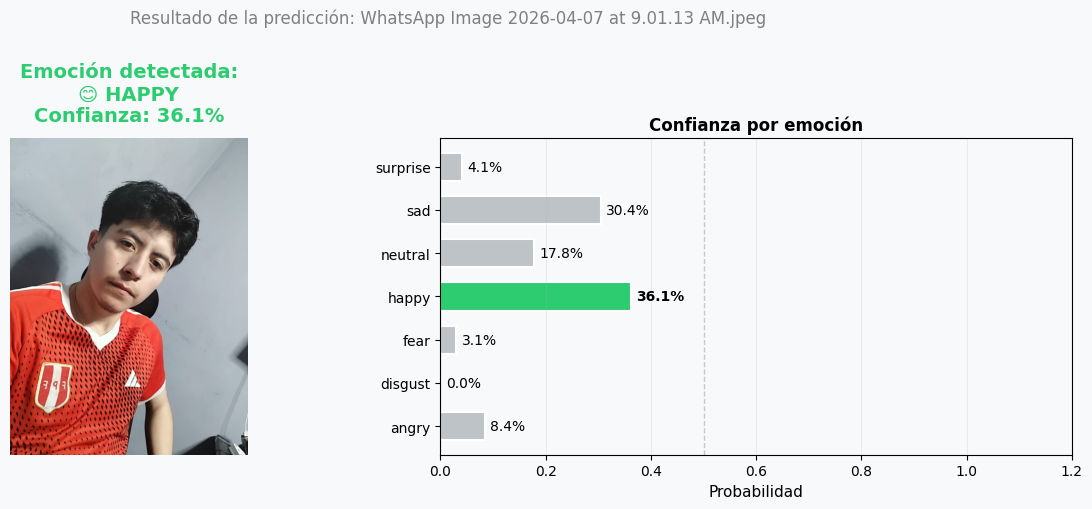


🎯 RESULTADO FINAL
   Emoción detectada: 😊 HAPPY
   Confianza:         36.1%

   Ranking de emociones:
   1. happy     : 36.1%  ███████
   2. sad       : 30.4%  ██████
   3. neutral   : 17.8%  ███
   4. angry     : 8.4%  █
   5. surprise  : 4.1%  
   6. fear      : 3.1%  
   7. disgust   : 0.0%  

🔍 Procesando: WhatsApp Image 2026-04-07 at 9.01.12 AM.jpeg


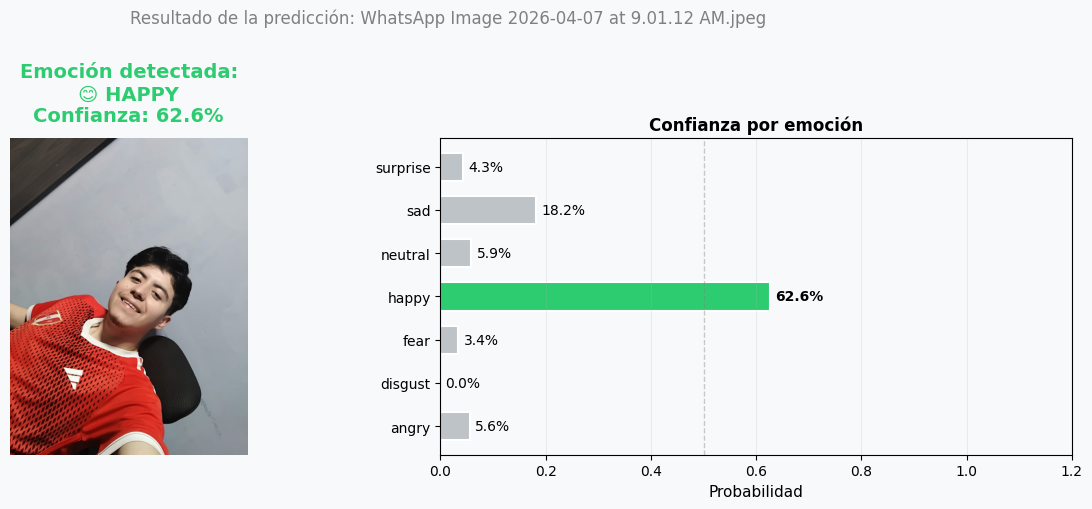


🎯 RESULTADO FINAL
   Emoción detectada: 😊 HAPPY
   Confianza:         62.6%

   Ranking de emociones:
   1. happy     : 62.6%  ████████████
   2. sad       : 18.2%  ███
   3. neutral   : 5.9%  █
   4. angry     : 5.6%  █
   5. surprise  : 4.3%  
   6. fear      : 3.4%  
   7. disgust   : 0.0%  


In [ ]:
# ============================================================
# CELDA 12 — PREDICE LA EMOCIÓN EN TU PROPIA FOTO (BONUS)
# ============================================================
# Aquí puedes subir una foto tuya o de cualquier persona
# y el modelo predecirá qué emoción tiene.
#
# IMPORTANTE: Para mejores resultados:
#   ✅ Usa una foto donde se vea bien el rostro
#   ✅ Fondo sencillo, buena iluminación
#   ✅ Rostro centrado y de frente
#   ❌ Evita fotos oscuras o con rostro muy pequeño
#
# El modelo fue entrenado con imágenes de 48x48 en escala de grises,
# así que redimensionará y convertirá tu foto automáticamente.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import json
from google.colab import files

# ----------------------------------------------------------
# Paso 1: Cargar el modelo y las clases guardadas
# ----------------------------------------------------------
print("📂 Cargando modelo y clases...")

# Cargamos el modelo entrenado
modelo = tf.keras.models.load_model('best_emotion_cnn.h5')

# Cargamos los nombres de las clases desde el JSON
with open('class_names.json', 'r') as f:
    clases = json.load(f)

print(f"✅ Modelo listo. Clases: {clases}")

# ----------------------------------------------------------
# Paso 2: Subir tu imagen desde la PC
# ----------------------------------------------------------
print("\n📸 Sube una foto con un rostro visible...")
print("   (JPG, PNG, o JPEG — se convertirá automáticamente a escala de grises)")

imagen_subida = files.upload()  # Abre el diálogo de selección de archivo

# ----------------------------------------------------------
# Emojis y colores para la visualización
#Angry (enojo): emoción negativa de irritación o enfado.
#Disgust (rechazo): emoción de repulsión que lleva a evitar algo desagradable.
#Fear (miedo): respuesta emocional ante una amenaza o peligro.
#Happy (felicidad): emoción positiva de alegría o bienestar.
#Neutral (neutral): ausencia de emoción evidente.
#Sad (tristeza): estado emocional de pena o desánimo.
#Surprise (sorpresa): reacción ante algo inesperado.
# ----------------------------------------------------------
emoji_map = {
    'angry': '😠', 'disgust': '🤢', 'fear': '😨',
    'happy': '😊', 'neutral': '😐', 'sad': '😢', 'surprise': '😲'
}

color_map = {
    'angry': '#e74c3c',   'disgust': '#8e44ad',
    'fear': '#3498db',    'happy': '#2ecc71',
    'neutral': '#95a5a6', 'sad': '#f39c12',
    'surprise': '#1abc9c'
}

# ----------------------------------------------------------
# Paso 3: Predecir la emoción de cada imagen subida
# ----------------------------------------------------------
for nombre_archivo in imagen_subida.keys():

    print(f"\n🔍 Procesando: {nombre_archivo}")

    # ── Preprocesamiento ──────────────────────────────────
    # Cargamos la imagen y la redimensionamos a 48x48 (igual que en entrenamiento)
    img = image.load_img(
        nombre_archivo,
        target_size=(48, 48),    # El modelo espera exactamente 48x48
        color_mode='grayscale'   # Convertimos a escala de grises
    )

    # Convertimos a array numpy y normalizamos de [0,255] a [0,1]
    img_array = image.img_to_array(img) / 255.0

    # Añadimos la dimensión de batch: (48, 48, 1) → (1, 48, 48, 1)
    img_input = np.expand_dims(img_array, axis=0)

    # ── Predicción ────────────────────────────────────────
    # El modelo devuelve 7 probabilidades (una por emoción)
    probabilidades = modelo.predict(img_input, verbose=0)[0]

    # La emoción predicha es la de mayor probabilidad
    idx_pred = np.argmax(probabilidades)
    emocion_pred = clases[idx_pred]
    confianza = probabilidades[idx_pred]

    # ── Visualización ─────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('#f8f9fa')  # Fondo gris claro del canvas

    # Panel izquierdo: imagen original (en color si la subiste en color)
    img_display = plt.imread(nombre_archivo)  # Leemos en color para mostrar
    axes[0].imshow(img_display)
    axes[0].axis('off')
    axes[0].set_title(
        f'Emoción detectada:\n'
        f'{emoji_map.get(emocion_pred, "?")} {emocion_pred.upper()}\n'
        f'Confianza: {confianza:.1%}',
        fontsize=14,
        fontweight='bold',
        color=color_map.get(emocion_pred, 'black'),
        pad=12
    )

    # Panel derecho: gráfico horizontal de probabilidades por emoción
    colores_barras = [
        color_map[c] if c == emocion_pred else '#bdc3c7'
        for c in clases
    ]

    bars = axes[1].barh(
        clases,
        probabilidades,
        color=colores_barras,
        edgecolor='white',
        linewidth=1.5,
        height=0.65
    )

    # Etiqueta de porcentaje al final de cada barra
    for bar, prob in zip(bars, probabilidades):
        axes[1].text(
            prob + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{prob:.1%}',
            va='center', fontsize=10,
            fontweight='bold' if prob == max(probabilidades) else 'normal',
            color='black'
        )

    # Línea vertical en 50% como referencia
    axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)

    axes[1].set_xlim(0, 1.2)
    axes[1].set_xlabel('Probabilidad', fontsize=11)
    axes[1].set_title('Confianza por emoción', fontsize=12, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.2)
    axes[1].set_facecolor('#f8f9fa')

    plt.suptitle(
        f'Resultado de la predicción: {nombre_archivo}',
        fontsize=12, y=1.01, color='gray'
    )
    plt.tight_layout()
    plt.savefig(f'prediccion_{nombre_archivo}', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Resumen en texto ──────────────────────────────────
    print(f"\n{'='*50}")
    print(f"🎯 RESULTADO FINAL")
    print(f"{'='*50}")
    print(f"   Emoción detectada: {emoji_map.get(emocion_pred,'?')} {emocion_pred.upper()}")
    print(f"   Confianza:         {confianza:.1%}")
    print(f"\n   Ranking de emociones:")
    # Ordenamos por probabilidad de mayor a menor
    ranking = sorted(zip(probabilidades, clases), reverse=True)
    for i, (prob, nombre) in enumerate(ranking, 1):
        barra = '█' * int(prob * 20)  # Barra de texto proporcional
        print(f"   {i}. {nombre:10s}: {prob:.1%}  {barra}")


📂 Cargando modelo y clases...


✅ Modelo listo. Clases: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

📸 Sube una foto con un rostro visible...
   (JPG, PNG, o JPEG — se convertirá automáticamente a escala de grises)


Saving WhatsApp Image 2026-04-09 at 11.11.35 PM.jpeg to WhatsApp Image 2026-04-09 at 11.11.35 PM.jpeg
Saving WhatsApp Image 2026-04-09 at 11.11.34 PM (2).jpeg to WhatsApp Image 2026-04-09 at 11.11.34 PM (2).jpeg
Saving WhatsApp Image 2026-04-09 at 11.11.34 PM (1).jpeg to WhatsApp Image 2026-04-09 at 11.11.34 PM (1).jpeg
Saving WhatsApp Image 2026-04-09 at 11.11.34 PM.jpeg to WhatsApp Image 2026-04-09 at 11.11.34 PM.jpeg

🔍 Procesando: WhatsApp Image 2026-04-09 at 11.11.35 PM.jpeg


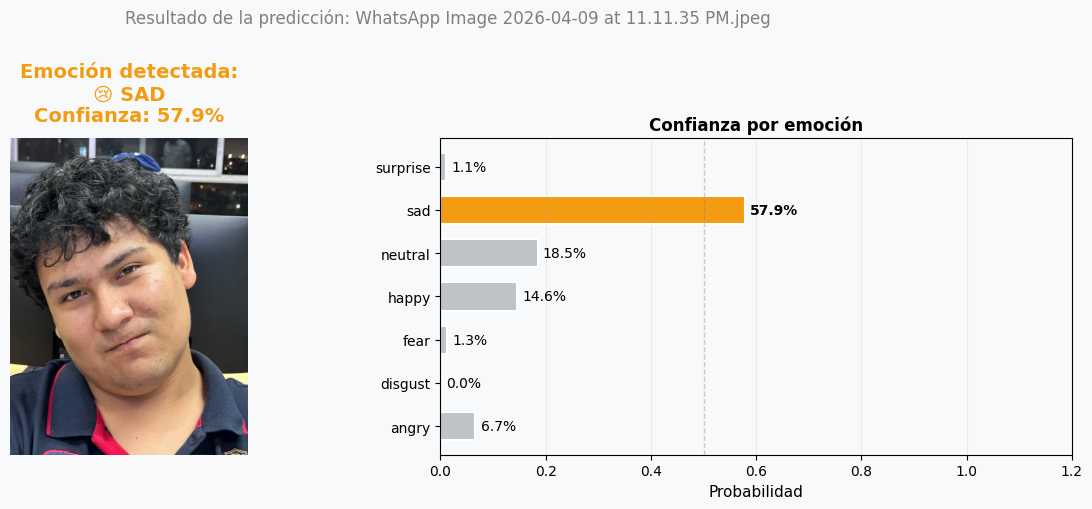


🎯 RESULTADO FINAL
   Emoción detectada: 😢 SAD
   Confianza:         57.9%

   Ranking de emociones:
   1. sad       : 57.9%  ███████████
   2. neutral   : 18.5%  ███
   3. happy     : 14.6%  ██
   4. angry     : 6.7%  █
   5. fear      : 1.3%  
   6. surprise  : 1.1%  
   7. disgust   : 0.0%  

🔍 Procesando: WhatsApp Image 2026-04-09 at 11.11.34 PM (2).jpeg


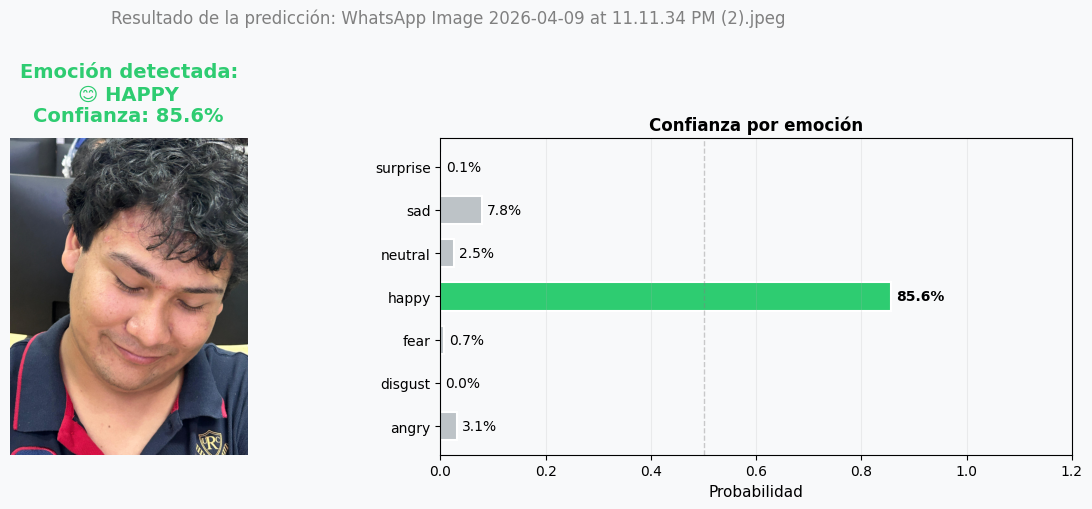


🎯 RESULTADO FINAL
   Emoción detectada: 😊 HAPPY
   Confianza:         85.6%

   Ranking de emociones:
   1. happy     : 85.6%  █████████████████
   2. sad       : 7.8%  █
   3. angry     : 3.1%  
   4. neutral   : 2.5%  
   5. fear      : 0.7%  
   6. surprise  : 0.1%  
   7. disgust   : 0.0%  

🔍 Procesando: WhatsApp Image 2026-04-09 at 11.11.34 PM (1).jpeg


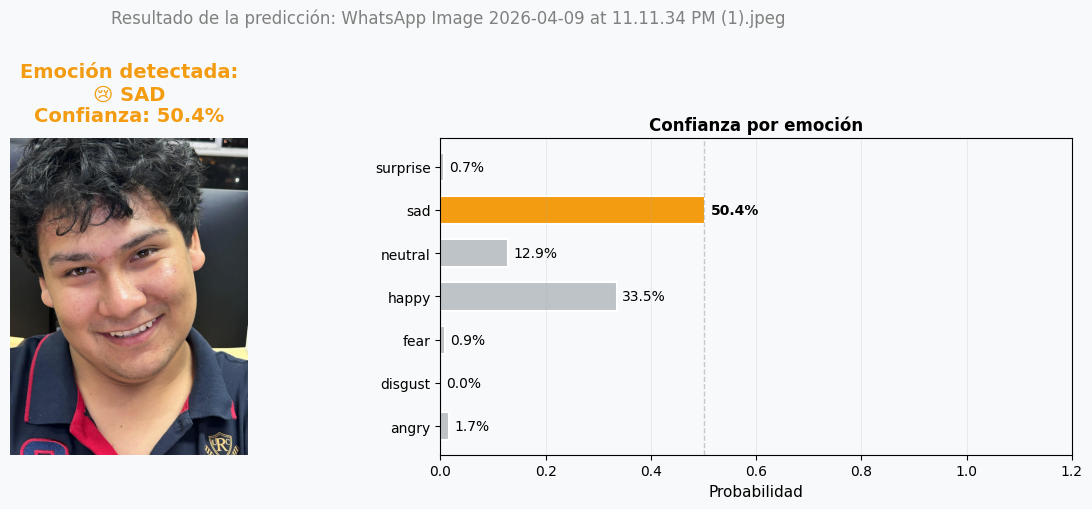


🎯 RESULTADO FINAL
   Emoción detectada: 😢 SAD
   Confianza:         50.4%

   Ranking de emociones:
   1. sad       : 50.4%  ██████████
   2. happy     : 33.5%  ██████
   3. neutral   : 12.9%  ██
   4. angry     : 1.7%  
   5. fear      : 0.9%  
   6. surprise  : 0.7%  
   7. disgust   : 0.0%  

🔍 Procesando: WhatsApp Image 2026-04-09 at 11.11.34 PM.jpeg


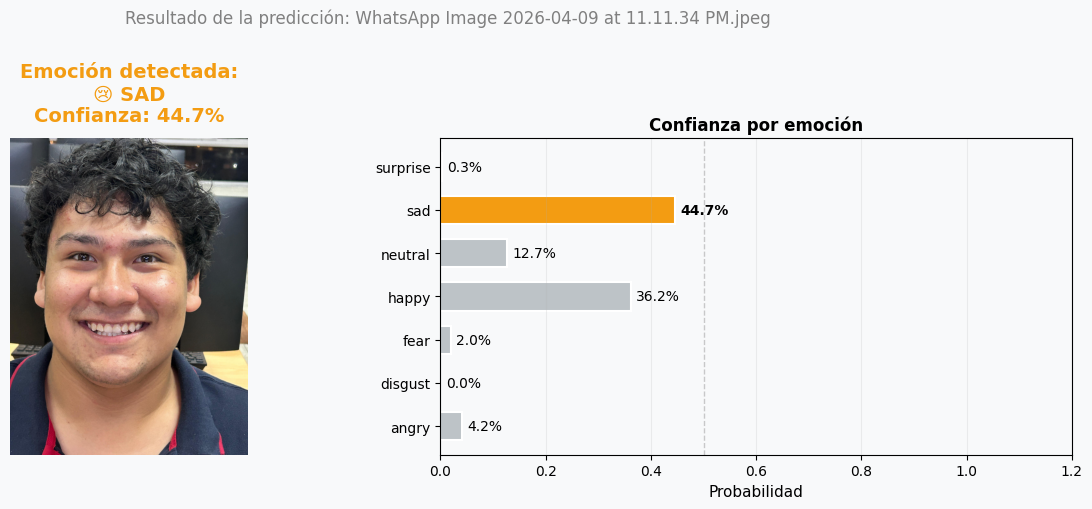


🎯 RESULTADO FINAL
   Emoción detectada: 😢 SAD
   Confianza:         44.7%

   Ranking de emociones:
   1. sad       : 44.7%  ████████
   2. happy     : 36.2%  ███████
   3. neutral   : 12.7%  ██
   4. angry     : 4.2%  
   5. fear      : 2.0%  
   6. surprise  : 0.3%  
   7. disgust   : 0.0%  


In [ ]:
# ============================================================
# CELDA 12 — PREDICE LA EMOCIÓN EN TU PROPIA FOTO (BONUS)
# ============================================================
# Aquí puedes subir una foto tuya o de cualquier persona
# y el modelo predecirá qué emoción tiene.
#
# IMPORTANTE: Para mejores resultados:
#   ✅ Usa una foto donde se vea bien el rostro
#   ✅ Fondo sencillo, buena iluminación
#   ✅ Rostro centrado y de frente
#   ❌ Evita fotos oscuras o con rostro muy pequeño
#
# El modelo fue entrenado con imágenes de 48x48 en escala de grises,
# así que redimensionará y convertirá tu foto automáticamente.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import json
from google.colab import files

# ----------------------------------------------------------
# Paso 1: Cargar el modelo y las clases guardadas
# ----------------------------------------------------------
print("📂 Cargando modelo y clases...")

# Cargamos el modelo entrenado
modelo = tf.keras.models.load_model('best_emotion_cnn.h5')

# Cargamos los nombres de las clases desde el JSON
with open('class_names.json', 'r') as f:
    clases = json.load(f)

print(f"✅ Modelo listo. Clases: {clases}")

# ----------------------------------------------------------
# Paso 2: Subir tu imagen desde la PC
# ----------------------------------------------------------
print("\n📸 Sube una foto con un rostro visible...")
print("   (JPG, PNG, o JPEG — se convertirá automáticamente a escala de grises)")

imagen_subida = files.upload()  # Abre el diálogo de selección de archivo

# ----------------------------------------------------------
# Emojis y colores para la visualización
#Angry (enojo): emoción negativa de irritación o enfado.
#Disgust (rechazo): emoción de repulsión que lleva a evitar algo desagradable.
#Fear (miedo): respuesta emocional ante una amenaza o peligro.
#Happy (felicidad): emoción positiva de alegría o bienestar.
#Neutral (neutral): ausencia de emoción evidente.
#Sad (tristeza): estado emocional de pena o desánimo.
#Surprise (sorpresa): reacción ante algo inesperado.
# ----------------------------------------------------------
emoji_map = {
    'angry': '😠', 'disgust': '🤢', 'fear': '😨',
    'happy': '😊', 'neutral': '😐', 'sad': '😢', 'surprise': '😲'
}

color_map = {
    'angry': '#e74c3c',   'disgust': '#8e44ad',
    'fear': '#3498db',    'happy': '#2ecc71',
    'neutral': '#95a5a6', 'sad': '#f39c12',
    'surprise': '#1abc9c'
}

# ----------------------------------------------------------
# Paso 3: Predecir la emoción de cada imagen subida
# ----------------------------------------------------------
for nombre_archivo in imagen_subida.keys():

    print(f"\n🔍 Procesando: {nombre_archivo}")

    # ── Preprocesamiento ──────────────────────────────────
    # Cargamos la imagen y la redimensionamos a 48x48 (igual que en entrenamiento)
    img = image.load_img(
        nombre_archivo,
        target_size=(48, 48),    # El modelo espera exactamente 48x48
        color_mode='grayscale'   # Convertimos a escala de grises
    )

    # Convertimos a array numpy y normalizamos de [0,255] a [0,1]
    img_array = image.img_to_array(img) / 255.0

    # Añadimos la dimensión de batch: (48, 48, 1) → (1, 48, 48, 1)
    img_input = np.expand_dims(img_array, axis=0)

    # ── Predicción ────────────────────────────────────────
    # El modelo devuelve 7 probabilidades (una por emoción)
    probabilidades = modelo.predict(img_input, verbose=0)[0]

    # La emoción predicha es la de mayor probabilidad
    idx_pred = np.argmax(probabilidades)
    emocion_pred = clases[idx_pred]
    confianza = probabilidades[idx_pred]

    # ── Visualización ─────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('#f8f9fa')  # Fondo gris claro del canvas

    # Panel izquierdo: imagen original (en color si la subiste en color)
    img_display = plt.imread(nombre_archivo)  # Leemos en color para mostrar
    axes[0].imshow(img_display)
    axes[0].axis('off')
    axes[0].set_title(
        f'Emoción detectada:\n'
        f'{emoji_map.get(emocion_pred, "?")} {emocion_pred.upper()}\n'
        f'Confianza: {confianza:.1%}',
        fontsize=14,
        fontweight='bold',
        color=color_map.get(emocion_pred, 'black'),
        pad=12
    )

    # Panel derecho: gráfico horizontal de probabilidades por emoción
    colores_barras = [
        color_map[c] if c == emocion_pred else '#bdc3c7'
        for c in clases
    ]

    bars = axes[1].barh(
        clases,
        probabilidades,
        color=colores_barras,
        edgecolor='white',
        linewidth=1.5,
        height=0.65
    )

    # Etiqueta de porcentaje al final de cada barra
    for bar, prob in zip(bars, probabilidades):
        axes[1].text(
            prob + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{prob:.1%}',
            va='center', fontsize=10,
            fontweight='bold' if prob == max(probabilidades) else 'normal',
            color='black'
        )

    # Línea vertical en 50% como referencia
    axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)

    axes[1].set_xlim(0, 1.2)
    axes[1].set_xlabel('Probabilidad', fontsize=11)
    axes[1].set_title('Confianza por emoción', fontsize=12, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.2)
    axes[1].set_facecolor('#f8f9fa')

    plt.suptitle(
        f'Resultado de la predicción: {nombre_archivo}',
        fontsize=12, y=1.01, color='gray'
    )
    plt.tight_layout()
    plt.savefig(f'prediccion_{nombre_archivo}', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Resumen en texto ──────────────────────────────────
    print(f"\n{'='*50}")
    print(f"🎯 RESULTADO FINAL")
    print(f"{'='*50}")
    print(f"   Emoción detectada: {emoji_map.get(emocion_pred,'?')} {emocion_pred.upper()}")
    print(f"   Confianza:         {confianza:.1%}")
    print(f"\n   Ranking de emociones:")
    # Ordenamos por probabilidad de mayor a menor
    ranking = sorted(zip(probabilidades, clases), reverse=True)
    for i, (prob, nombre) in enumerate(ranking, 1):
        barra = '█' * int(prob * 20)  # Barra de texto proporcional
        print(f"   {i}. {nombre:10s}: {prob:.1%}  {barra}")